# US Visa Prediction Project
**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Exploratory data analysis
* Data Cleaning
* Data Pre-Processing
* Model Training 
* Choose best model

### About
The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. 
The act also protects US workers against adverse impacts on working place and maintain requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

## **1) Problem statement.**

* OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications. 
* As In last year the count of employees were huge so OFLC needs Machine learning models to shortlist visa applicants based on their previous data.

**In this project we are going to use the data given to build a Classification model:**

* This model is to check if Visa get approved or not based on the given dataset.
* This can be used to Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the certain criteria which influences the decision.

## **2) Data Collection.**
* The Dataset is part of Office of Foreign Labor Certification (OFLC)
* The data consists of 25480 Rows and 12 Columns

* Data Source: https://www.kaggle.com/datasets/moro23/easyvisa-dataset

### 2.1 Import Data and Required Packages

**Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

**Import the CSV Data as Pandas DataFrame**

In [5]:
df = pd.read_csv(r"visa_dataset.csv")

## **3. Initial Data Exploration**

**Show Top 5 Records**

In [6]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Shape of the dataset**

In [7]:
df.shape

(25480, 12)

**Check Datatypes in the dataset**

In [8]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Summary of the dataset**

In [9]:
# Display summary statistics for a dataframe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


### 3.1) Data Quality
- Missing values
- Duplicates
- Data types
- Unique values
- Invalid values

**Missing values**

In [10]:
# Check the number of missing values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [11]:
# Calculate missing-value percentage for each column
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage

case_id                  0.0
continent                0.0
education_of_employee    0.0
has_job_experience       0.0
requires_job_training    0.0
no_of_employees          0.0
yr_of_estab              0.0
region_of_employment     0.0
prevailing_wage          0.0
unit_of_wage             0.0
full_time_position       0.0
case_status              0.0
dtype: float64

**Duplicates**

In [12]:
# Count completely duplicated rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [13]:
# Calculate percentage of duplicated rows
duplicate_percentage = df.duplicated().mean() * 100

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate percentage: 0.00%


**Data types**

In [14]:
# Check column data types and non-null information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [15]:
# Create a compact data-type summary
dtype_summary = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Non_Null_Count": df.notnull().sum(),
    "Unique_Values": df.nunique()
})

dtype_summary

,Data_Type,Non_Null_Count,Unique_Values
case_id,object,25480,25480
continent,object,25480,6
education_of_employee,object,25480,4
has_job_experience,object,25480,2
requires_job_training,object,25480,2
no_of_employees,int64,25480,7105
yr_of_estab,int64,25480,199
region_of_employment,object,25480,5
prevailing_wage,float64,25480,25454
unit_of_wage,object,25480,4


In [16]:
# define numerical & categorical columns

# Identify categorical features
numerical_features = df.select_dtypes(exclude="object").columns.tolist()

# Identify categorical features
categorical_features = df.select_dtypes(include="object").columns.tolist()

# Using f-strings (cleaner than .format())
print(f"We have {len(numerical_features)} numerical features : {numerical_features}")
print(f"We have {len(categorical_features)} categorical features : {categorical_features}")

We have 3 numerical features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
We have 9 categorical features : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


### Insight
- Why separate them?
    - Numerical features require continuous statistical tools: histograms, KDE plots, box plots (outlier checks), and correlation matrices.

    - Categorical features require discrete statistical tools: frequency counts (value_counts), bar charts, pie charts, and contingency tables (Chi-square tests).


- Doing this early makes our upcoming loops for plotting automated and clean.

**Unique values**

In [17]:
# Check the number of unique values in every feature
unique_values = df.nunique().sort_values(ascending=False)

unique_values

case_id                  25480
prevailing_wage          25454
no_of_employees           7105
yr_of_estab                199
continent                    6
region_of_employment         5
unit_of_wage                 4
education_of_employee        4
has_job_experience           2
requires_job_training        2
full_time_position           2
case_status                  2
dtype: int64

In [18]:
# Display unique values of categorical features
for column in categorical_features:
    print(f"\n{column}:")
    print(df[column].unique())


case_id:
['EZYV01' 'EZYV02' 'EZYV03' ... 'EZYV25478' 'EZYV25479' 'EZYV25480']

continent:
['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']

education_of_employee:
['High School' "Master's" "Bachelor's" 'Doctorate']

has_job_experience:
['N' 'Y']

requires_job_training:
['N' 'Y']

region_of_employment:
['West' 'Northeast' 'South' 'Midwest' 'Island']

unit_of_wage:
['Hour' 'Year' 'Week' 'Month']

full_time_position:
['Y' 'N']

case_status:
['Denied' 'Certified']


- Key note:
    - Unique-value analysis helps identify:
    - Feature have 'Y' , 'N' , 'YES' , 'NO' 
    - then the dataset contains inconsistent representations that should be cleaned.

**Invalid values**

In [19]:
# Generate descriptive statistics for numerical features
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


In [20]:
# Display value frequencies for categorical features
for column in categorical_features:
    print(f"\n{'=' * 60}")
    print(f"Feature: {column}")
    print(df[column].value_counts(dropna=False))


Feature: case_id
case_id
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
EZYV05       1
            ..
EZYV25476    1
EZYV25477    1
EZYV25478    1
EZYV25479    1
EZYV25480    1
Name: count, Length: 25480, dtype: int64

Feature: continent
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

Feature: education_of_employee
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

Feature: has_job_experience
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

Feature: requires_job_training
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

Feature: region_of_employment
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64

Feature: unit_of_wage
unit_of_wage
Year    

In [21]:
# Check categorical columns for leading/trailing whitespace
for column in categorical_features:
    whitespace_count = (
        df[column].astype("string").str.strip() != df[column].astype("string")
    ).sum()

    if whitespace_count > 0:
        print(f"{column}: {whitespace_count} values contain extra whitespace")

**Insight**
- Invisible spaces can create separate categories.

- for example: 
    - "Master's"
    - "Master's "

    - Python considers these different strings.
    - This can negatively affect encoding and model training.

In [22]:
# Find features containing only one unique value
constant_features = [
    column for column in df.columns
    if df[column].nunique(dropna=False) <= 1
]

print("Constant Features:", constant_features)

Constant Features: []


**Insight**

- If a feature has:
    - 25480 records
    - 25480 = same value

    - then it doesn't help the model distinguish between visa outcomes.
    - Such features are candidates for removal.

#### Data Quality Summary

In [23]:
# Create a comprehensive data-quality summary
data_quality_summary = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100,
    "Unique_Count": df.nunique(),
    "Duplicate_Count": df.duplicated().sum()
})

data_quality_summary

,Data_Type,Missing_Count,Missing_Percentage,Unique_Count,Duplicate_Count
case_id,object,0,0.0,25480,0
continent,object,0,0.0,6,0
education_of_employee,object,0,0.0,4,0
has_job_experience,object,0,0.0,2,0
requires_job_training,object,0,0.0,2,0
no_of_employees,int64,0,0.0,7105,0
yr_of_estab,int64,0,0.0,199,0
region_of_employment,object,0,0.0,5,0
prevailing_wage,float64,0,0.0,25454,0
unit_of_wage,object,0,0.0,4,0


In [24]:
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

case_id
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
EZYV05       0.003925
               ...   
EZYV25476    0.003925
EZYV25477    0.003925
EZYV25478    0.003925
EZYV25479    0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
---------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
---------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
---------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
---------------------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
---------------------------
region_of_employment
Northeast    2

**Insights**
 - `case_id` have unique values for each column which can be dropped as it is of no importance
 - `continent` column is highly biased towards asia. hence we can combine other categories to form a single category.
 - `unit_of_wage` seems to be an important column as most of them are yearly contracts.

### 3.2 Univariate Analysis
│
├── 3.2.1 Categorical Features
│   ├── Frequency distribution
│   ├── Percentage distribution
│   └── Visualization
│
└── 3.2.2 Numerical Features
    ├── Descriptive statistics
    ├── Distribution
    ├── Skewness
    └── Outliers

* The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.

Other Type of Analysis are
* **Bivariate Analysis:** The analysis of two variables.
* **Multivariate Analysis:** The analysis of two or more variables.

### 3.2.1 Categorical Features

**Frequency + Percentage Distribution (Combined Table)**

In [25]:
# 3.2.1-A: Frequency & Percentage for all categorical features
for col in categorical_features:
    print(f"\n{'='*50}")
    print(f"Feature: {col.upper()}")
    print(f"{'='*50}")
    
    freq = pd.DataFrame({
        "Count": df[col].value_counts(),
        "Percentage (%)": (df[col].value_counts(normalize=True) * 100).round(2)
    })
    print(freq)


Feature: CASE_ID
           Count  Percentage (%)
case_id                         
EZYV01         1             0.0
EZYV02         1             0.0
EZYV03         1             0.0
EZYV04         1             0.0
EZYV05         1             0.0
...          ...             ...
EZYV25476      1             0.0
EZYV25477      1             0.0
EZYV25478      1             0.0
EZYV25479      1             0.0
EZYV25480      1             0.0

[25480 rows x 2 columns]

Feature: CONTINENT
               Count  Percentage (%)
continent                           
Asia           16861           66.17
Europe          3732           14.65
North America   3292           12.92
South America    852            3.34
Africa           551            2.16
Oceania          192            0.75

Feature: EDUCATION_OF_EMPLOYEE
                       Count  Percentage (%)
education_of_employee                       
Bachelor's             10234           40.16
Master's                9634           37.81

- Key Insight:
- The categorical features show several imbalanced distributions, particularly `CONTINENT`, `REQUIRES_JOB_TRAINING`, `UNIT_OF_WAGE`, and `FULL_TIME_POSITION`. `CASE_STATUS` also shows moderate class imbalance (66.79% Certified vs. 33.21% Denied). 

- `CASE_ID` is a unique identifier and should not be used as a predictive feature. These distributions will be further investigated through visualization and bivariate analysis to determine their relationship with visa approval status.

**Visualization (Count Plots for All Categorical Features)**

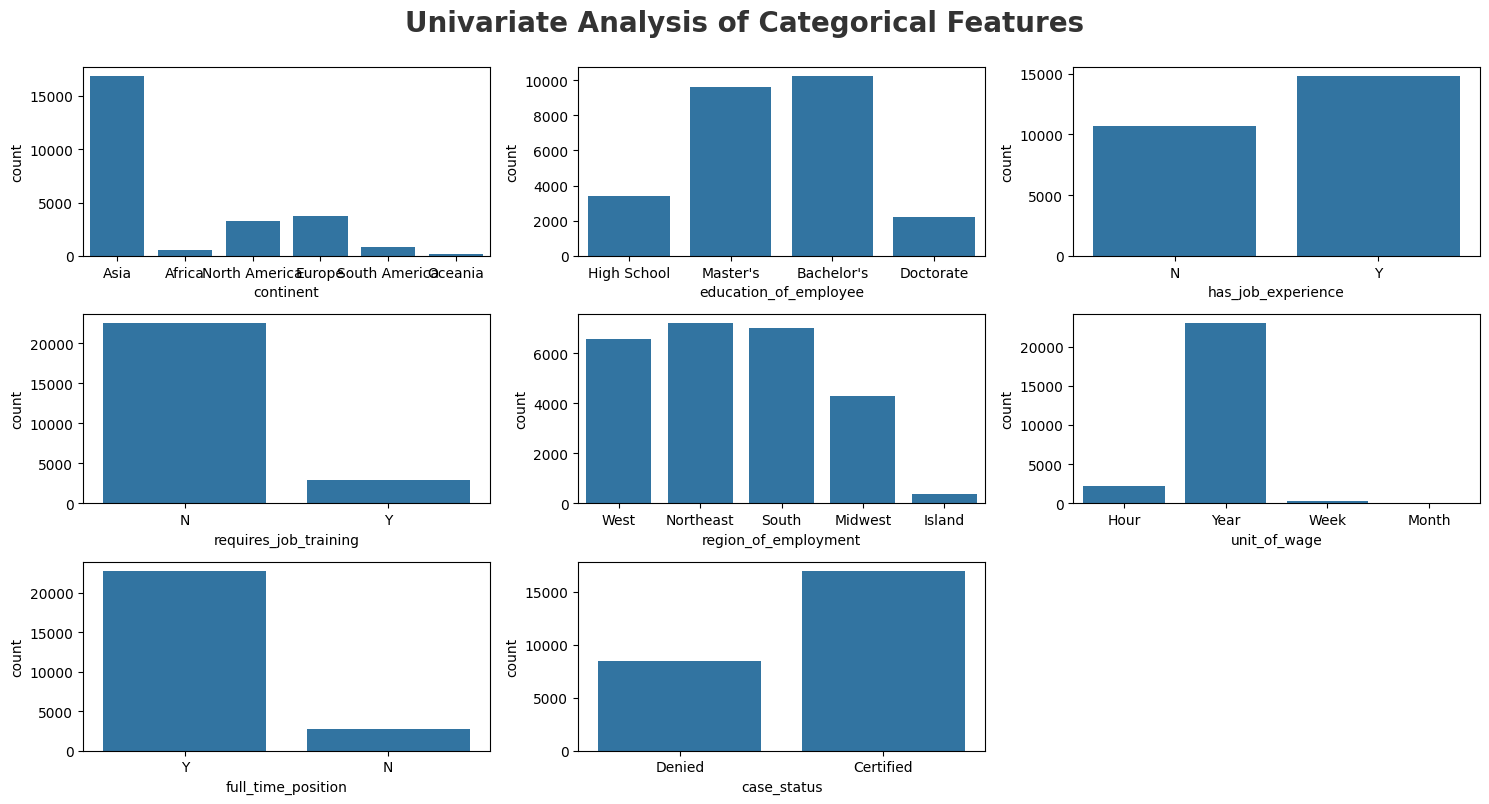

In [26]:
# categorical columns
categorical_features.remove('case_id')
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()
    
# save plot
# plt.savefig('./images/Univariate_Cat.png')

In [29]:
categorical_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

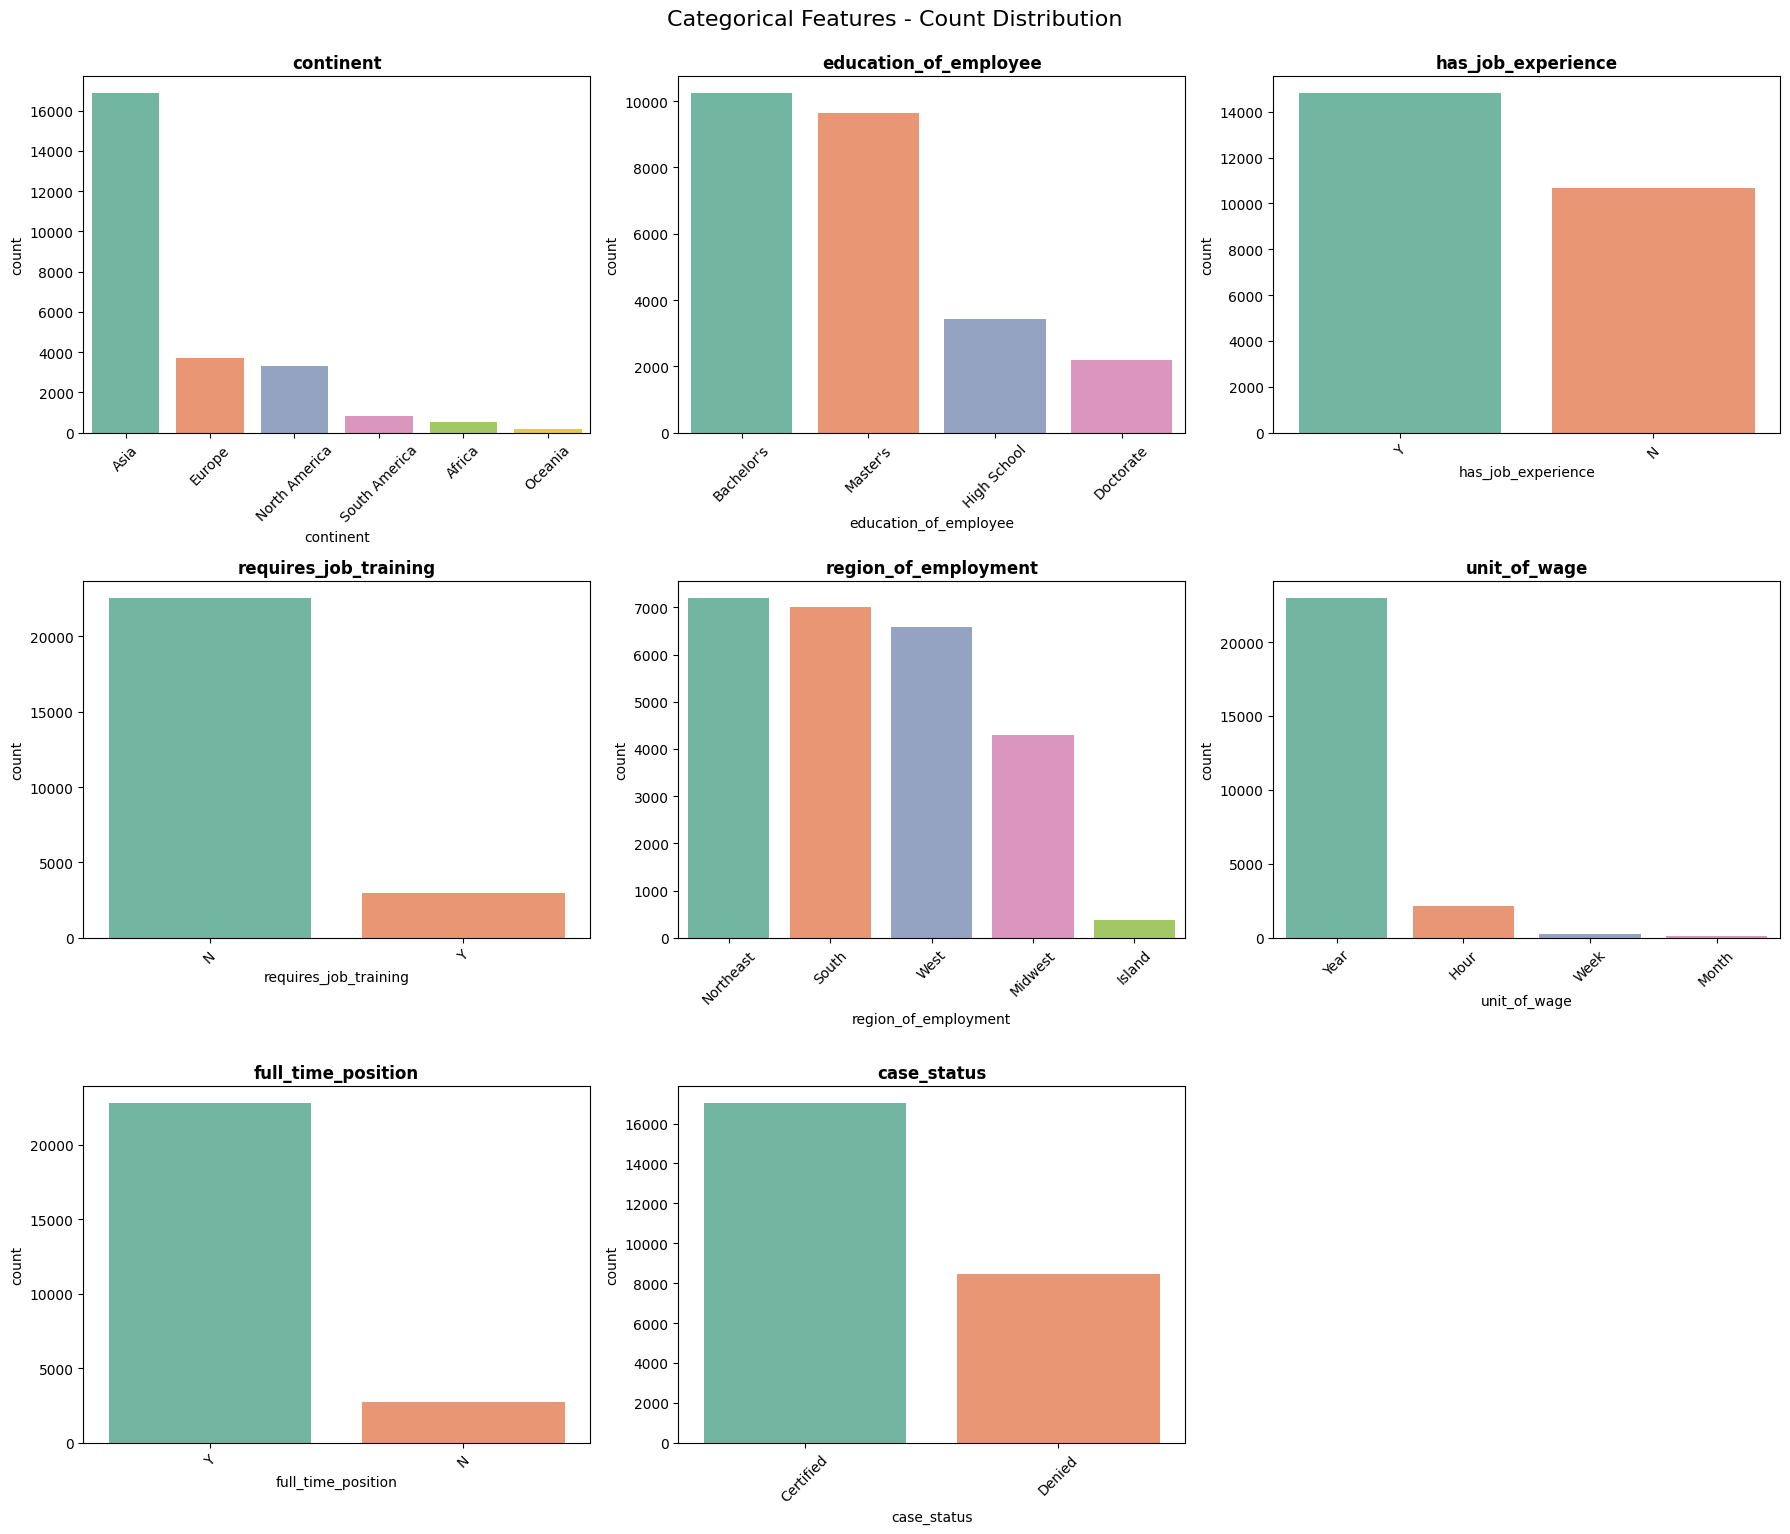

In [28]:
# 3.2.1-B: Count plots for all categorical features
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    if idx < len(axes):
        sns.countplot(data=df, x=col, ax=axes[idx], palette="Set2",
                      order=df[col].value_counts().index)
        axes[idx].set_title(f"{col}", fontsize=12, fontweight="bold")
        axes[idx].tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(categorical_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.suptitle("Categorical Features - Count Distribution", fontsize=16, y=1.02)
plt.show()

**Insights**
 - `requires_job_training`, `unit_of_wage`, `full_time_position` and `continents` columns have signle category dominating.
 - In rest of the columns are balanced.

In [30]:
# Check the number of categories in each categorical feature
categorical_cardinality = (
    df[categorical_features]
    .nunique()
    .sort_values(ascending=False)
)

categorical_cardinality

continent                6
region_of_employment     5
unit_of_wage             4
education_of_employee    4
requires_job_training    2
has_job_experience       2
full_time_position       2
case_status              2
dtype: int64

### 3.2.2 Numerical Features

**Descriptive Statistics & Skewness Table**

In [32]:
# 3.2.2-A: Summary Statistics & Skewness for Numerical Features
numeric_features = df.select_dtypes(exclude="object").columns.tolist()

num_summary = df[numeric_features].describe().T
num_summary["skewness"] = df[numeric_features].skew()
num_summary["kurtosis"] = df[numeric_features].kurtosis()

print("--- Numerical Features Summary ---")
display(num_summary[["mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "kurtosis"]].round(2))

--- Numerical Features Summary ---


,mean,std,min,25%,50%,75%,max,skewness,kurtosis
no_of_employees,5667.04,22877.93,-26.00,1022.00,2109.00,3504.00,602069.00,12.27,206.34
yr_of_estab,1979.41,42.37,1800.00,1976.00,1997.00,2005.00,2016.00,-2.04,3.51
prevailing_wage,74455.81,52815.94,2.14,34015.48,70308.21,107735.51,319210.27,0.76,0.82


**Distribution Analysis (Histograms + KDE)**

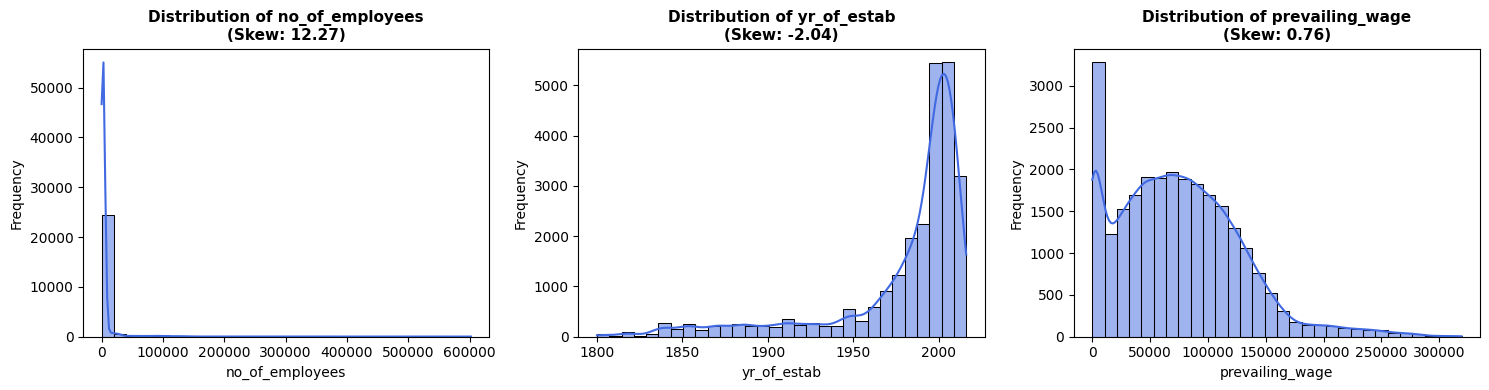

In [33]:
# 3.2.2-B: Histograms & KDE Distributions
plt.figure(figsize=(15, 4))

for i, col in enumerate(numeric_features):
    plt.subplot(1, len(numeric_features), i + 1)
    sns.histplot(df[col], kde=True, color="royalblue", bins=30)
    plt.title(f"Distribution of {col}\n(Skew: {df[col].skew():.2f})", fontsize=11, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

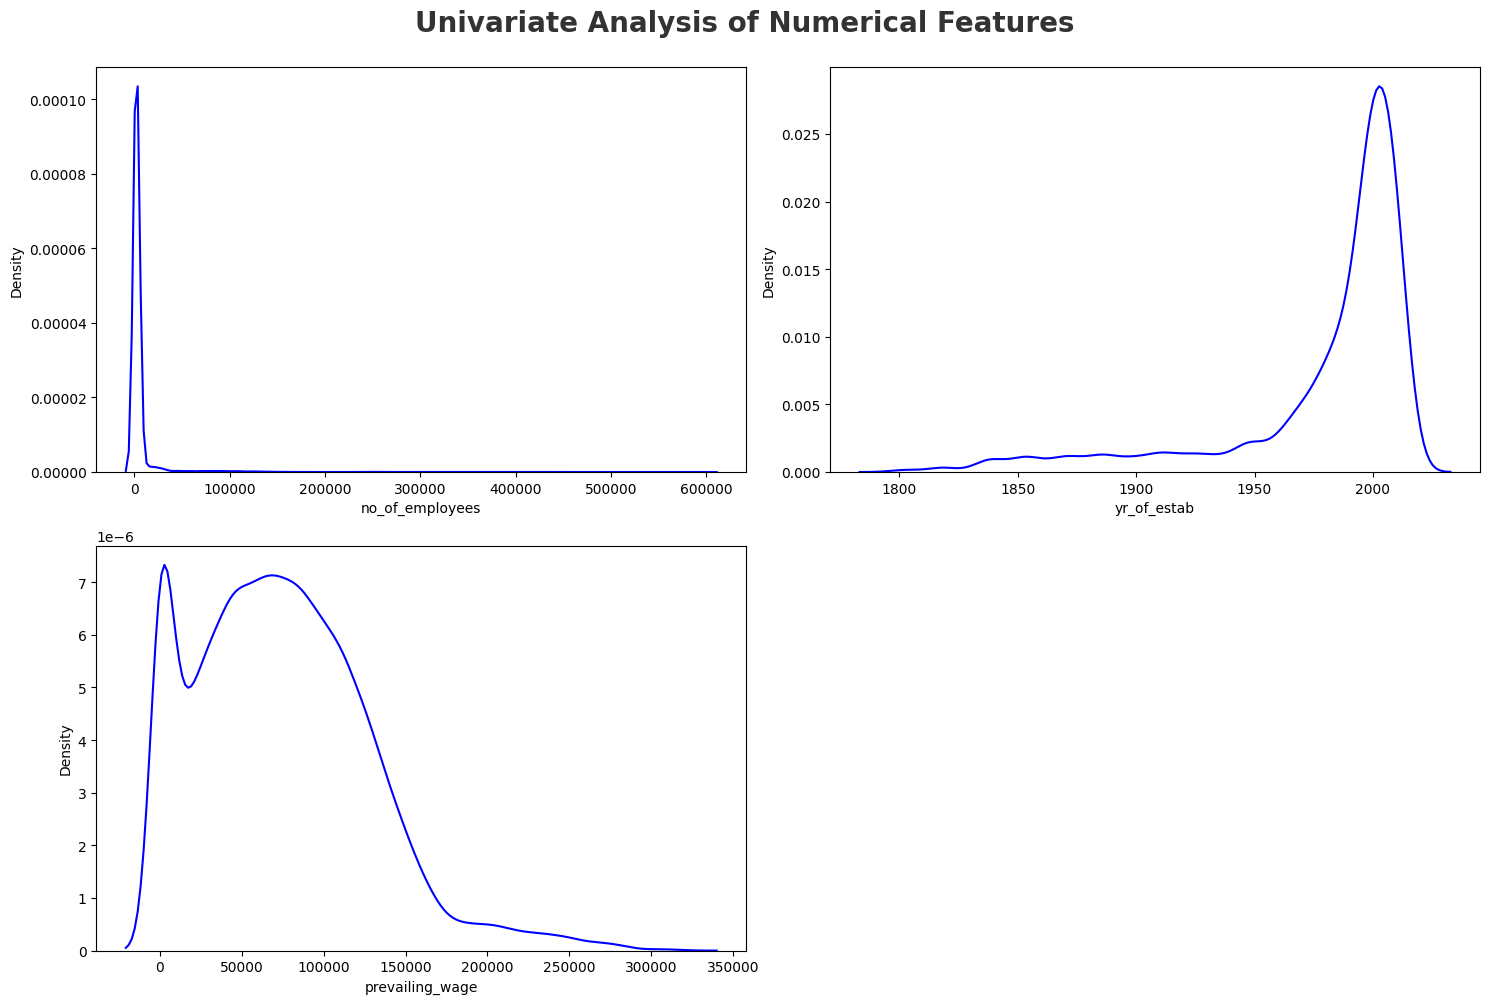

In [34]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()
    
# save plot
# plt.savefig('./images/Univariate_Num.png')

**Insights**
 - `no_of_employees` column looks more skewed but it may be because of outlies.
 - `yr_of_estab` is a discrete feature.
 - `privailing-wage` is a right-skewed distribution.

**Outlier Detection (Box Plots & IQR Quantification)**

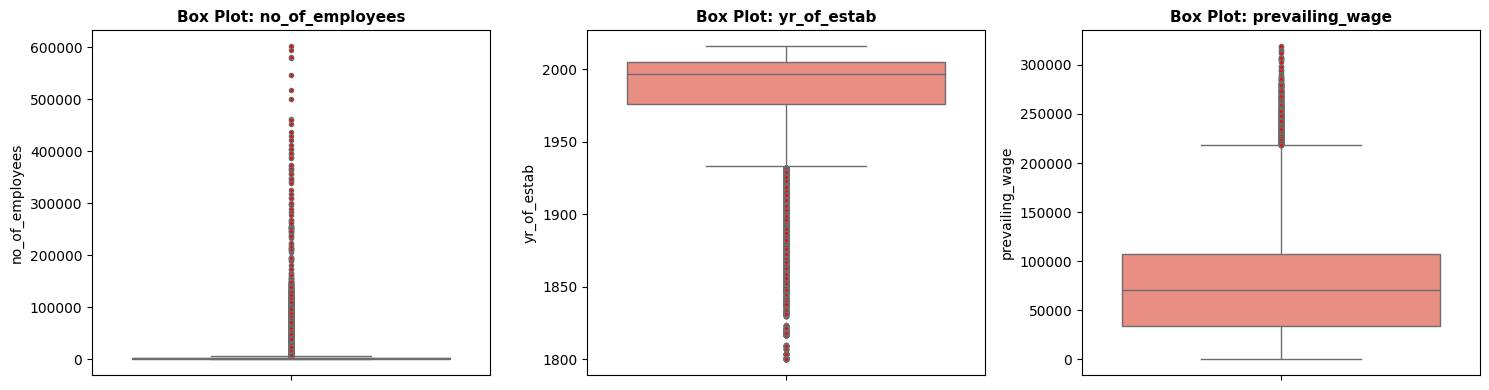

--- Outlier Summary (IQR Method) ---
no_of_employees: 1556 outliers (6.11%)
yr_of_estab: 3260 outliers (12.79%)
prevailing_wage: 427 outliers (1.68%)


In [35]:
# 3.2.2-C: Box Plots for Outlier Visualization
plt.figure(figsize=(15, 4))

for i, col in enumerate(numeric_features):
    plt.subplot(1, len(numeric_features), i + 1)
    sns.boxplot(y=df[col], color="salmon", flierprops=dict(markerfacecolor='red', markersize=3))
    plt.title(f"Box Plot: {col}", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# Calculate IQR Outlier Count and Percentage
print("--- Outlier Summary (IQR Method) ---")
for col in numeric_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers) / len(df) * 100:.2f}%)")

### 3.3: Target Variable Deep Dive

**3.3.1 Identify the Target Variable**

In [36]:
# Define the target variable
target_column = "case_status"

print(f"Target Variable: {target_column}")

Target Variable: case_status


**Insight**

- `CASE_STATUS` is the target/dependent variable because the objective of the project is to predict whether a visa application is Certified or Denied.

In [38]:
# Calculate the ratio between the majority and minority classes
class_counts = df[target_column].value_counts()

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

imbalance_ratio = (
    class_counts[majority_class] /
    class_counts[minority_class]
)

print(f"Majority Class : {majority_class}")
print(f"Minority Class : {minority_class}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

Majority Class : Certified
Minority Class : Denied
Imbalance Ratio: 2.01:1


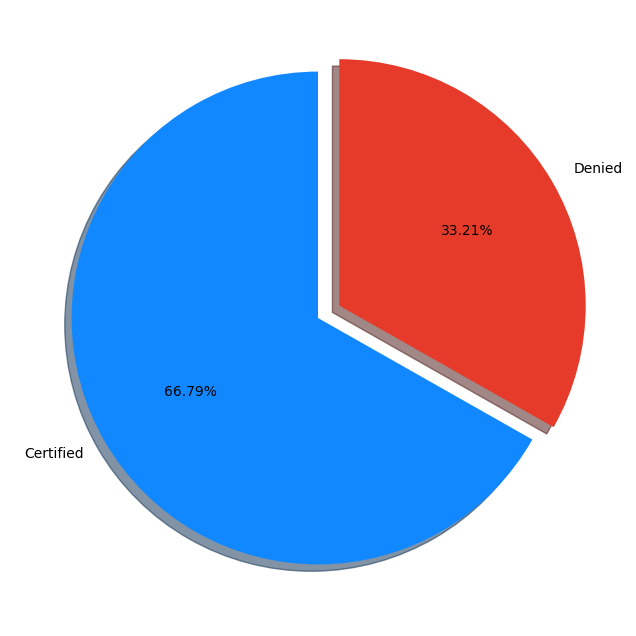

In [ ]:
###  Visualize the Target Feature
percentage = df.case_status.value_counts(normalize=True)*100
labels = ["Certified","Denied"]

# Plot PieChart with Ploty library
fig, ax = plt.subplots(figsize =(15, 8))
explode = (0, 0.1)
colors = ['#1188ff','#e63a2a']
ax.pie(percentage, labels = labels, startangle = 90,
       autopct='%1.2f%%',explode=explode, shadow=True, colors=colors)
plt.show()


* From the chart it is seen that the Target Variable is Imbalanced
**What is imbalanced data?**

- Imbalanced data are types of data where the target class has an uneven distribution of observations, i.e Here Denied value has more count than the Certified value of the dataset.

**Target Variable Calculation & Visualization**

--- Target Summary (case_status) ---
Certified Count : 17,018 (66.79%)
Denied Count    : 8,462 (33.21%)
Imbalance Ratio : 2.01 : 1 (Certified : Denied)



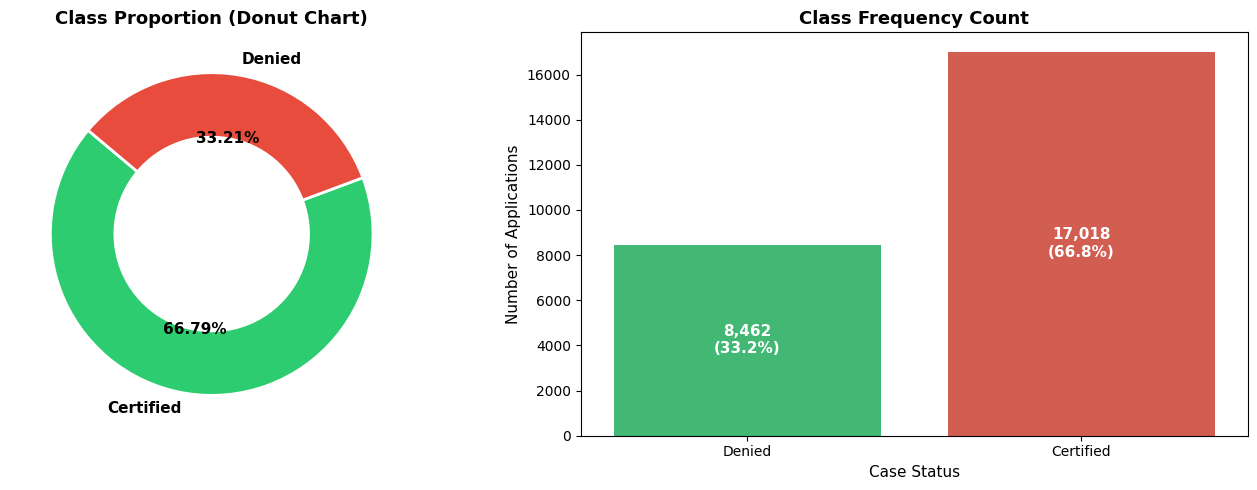

In [37]:
# 3.3 Target Variable Deep Dive: Distribution, Imbalance Ratio & Visuals
target_col = "case_status"

# Counts and Percentages
target_counts = df[target_col].value_counts()
target_pct = df[target_col].value_counts(normalize=True) * 100
imbalance_ratio = target_counts["Certified"] / target_counts["Denied"]

print(f"--- Target Summary ({target_col}) ---")
print(f"Certified Count : {target_counts['Certified']:,} ({target_pct['Certified']:.2f}%)")
print(f"Denied Count    : {target_counts['Denied']:,} ({target_pct['Denied']:.2f}%)")
print(f"Imbalance Ratio : {imbalance_ratio:.2f} : 1 (Certified : Denied)\n")

# Visualizations: Donut Chart + Annotated Count Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Donut Chart
colors = ["#2ecc71", "#e74c3c"]
axes[0].pie(
    target_counts,
    labels=target_counts.index,
    autopct="%1.2f%%",
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
    textprops={"fontsize": 11, "fontweight": "bold"}
)
axes[0].set_title("Class Proportion (Donut Chart)", fontsize=13, fontweight="bold")

# 2. Count Plot with Exact Value and Percentage Labels
sns.countplot(data=df, x=target_col, ax=axes[1], palette=colors)
axes[1].set_title("Class Frequency Count", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Case Status", fontsize=11)
axes[1].set_ylabel("Number of Applications", fontsize=11)

for p in axes[1].patches:
    count = int(p.get_height())
    pct = (count / len(df)) * 100
    axes[1].annotate(
        f"{count:,}\n({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2.0, count / 2),
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()
plt.show()

- Key Note:
    - The target variable CASE_STATUS contains two classes: Certified and Denied. Certified applications account for 66.79% of the dataset, while Denied applications account for 33.21%. Therefore, the target distribution shows moderate class imbalance with an approximate 2.01:1 majority-to-minority ratio. This imbalance should be considered during model evaluation, and accuracy alone should not be used as the primary evaluation metric. Precision, Recall, F1-score, ROC-AUC, and the Confusion Matrix should also be considered.

    - Additionally, target encoding should map Certified -> 1 (positive class) and Denied -> 0 (negative class) or evaluate resampling techniques (e.g., SMOTE) if tree models underperform on minority class recall.

## 3.4) Multivariate Analysis

### 3.4.1 : Bivariate Analysis

**Categorical Features vs. Target (case_status)**

In [40]:
pd.crosstab(
    df["education_of_employee"],
    df["case_status"]
)

case_status,Certified,Denied
education_of_employee,,
Bachelor's,6367,3867
Doctorate,1912,280
High School,1164,2256
Master's,7575,2059


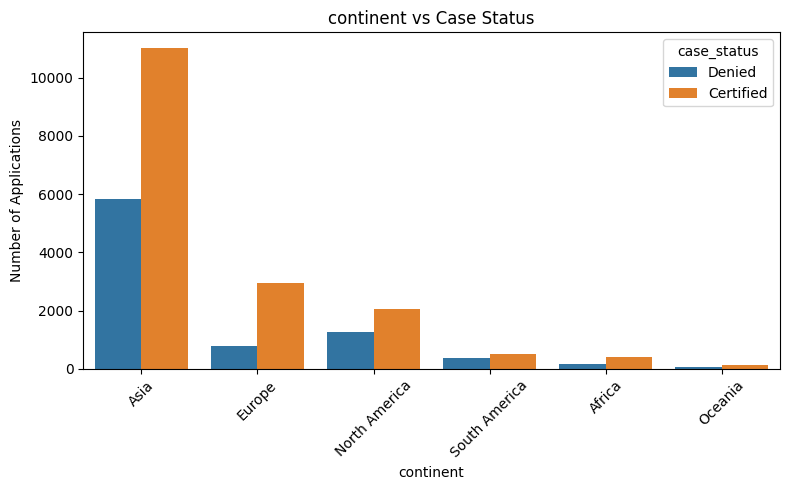

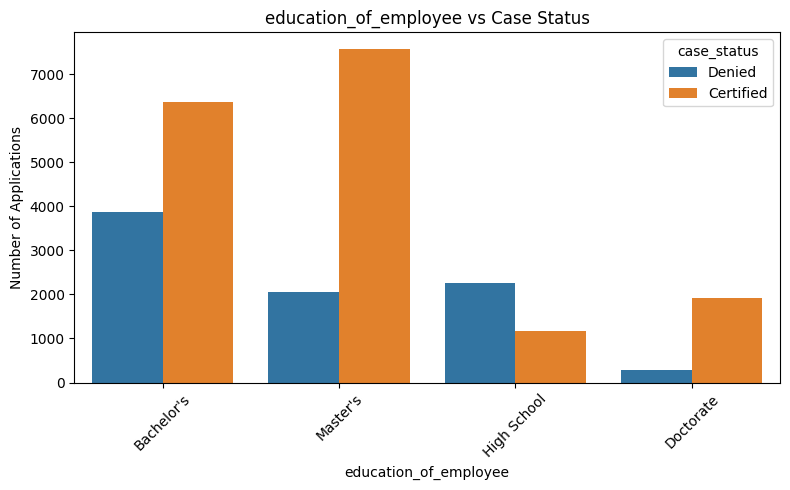

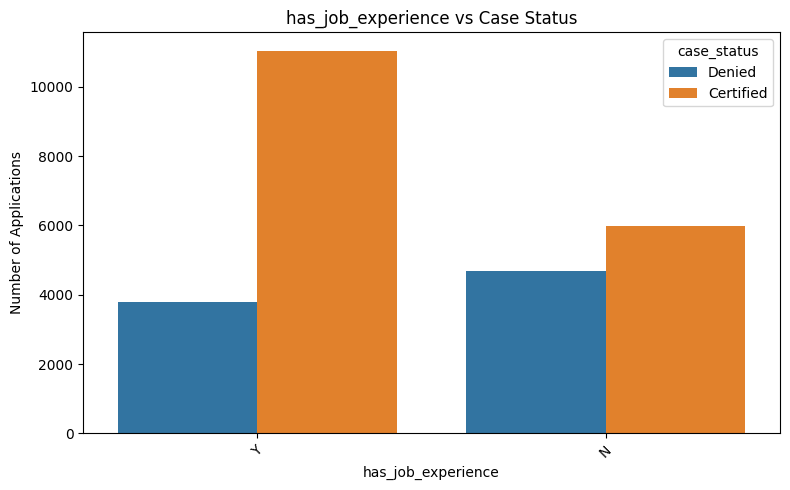

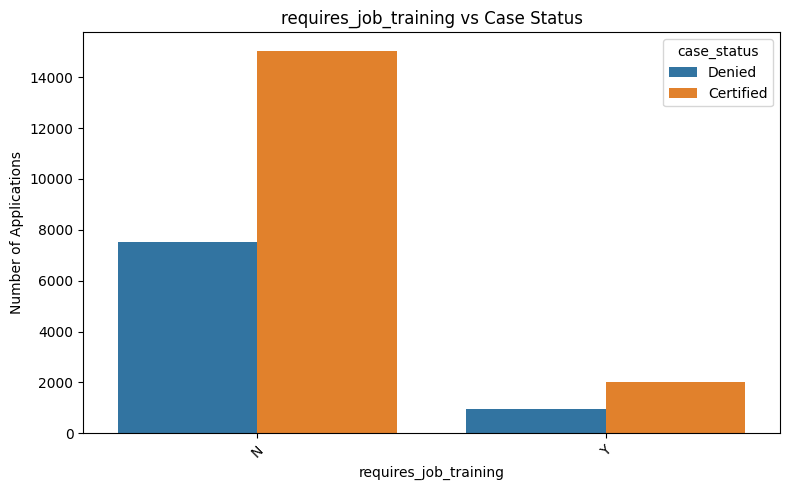

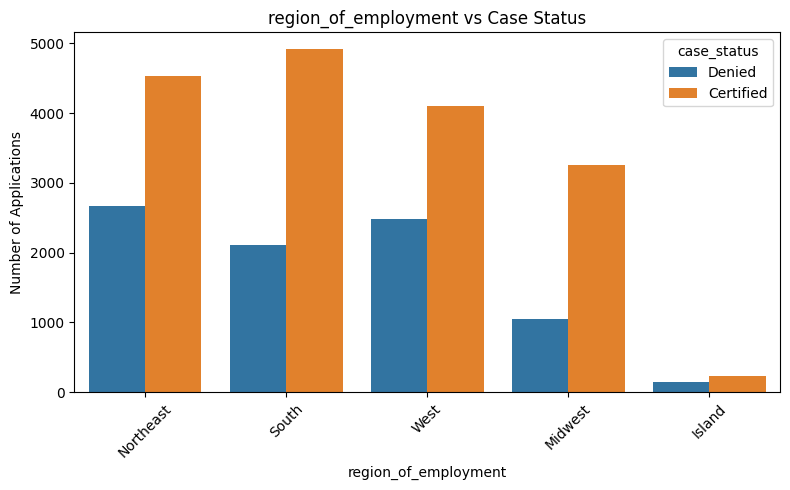

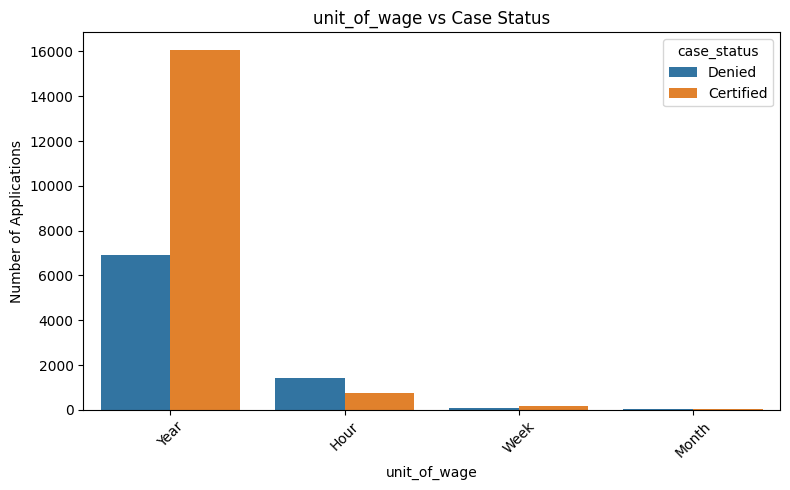

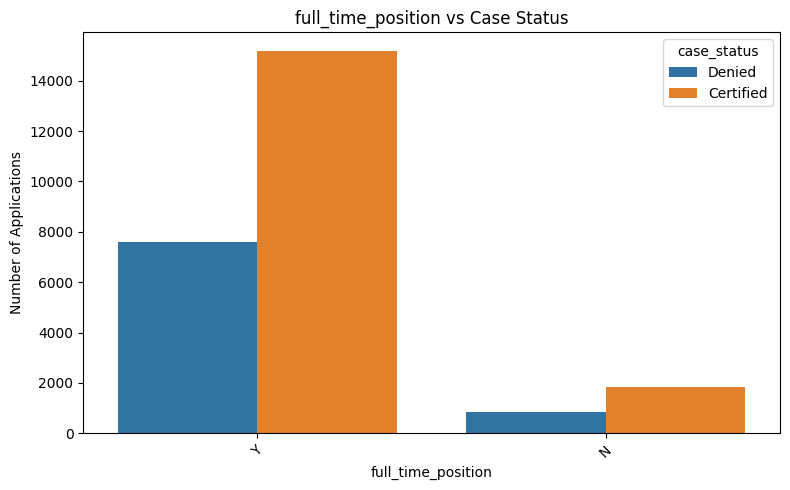

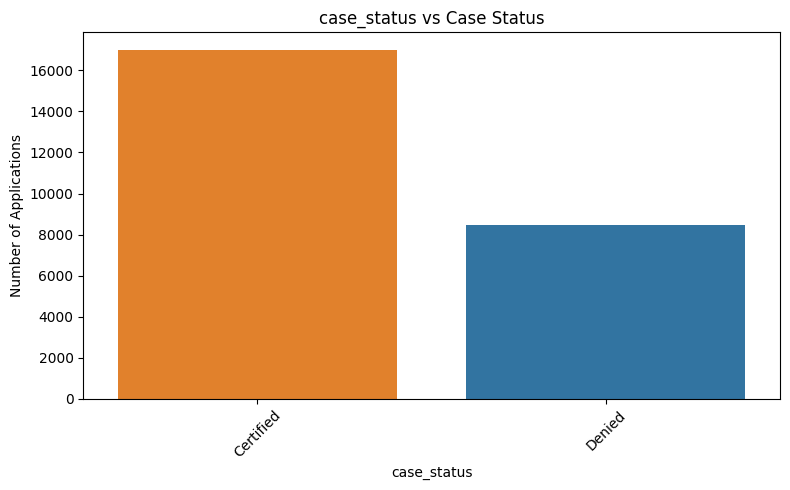

In [41]:
# Visualize categorical features against the target
for col in categorical_features:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=col,
        hue="case_status",
        order=df[col].value_counts().index
    )

    plt.title(f"{col} vs Case Status")
    plt.xlabel(col)
    plt.ylabel("Number of Applications")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

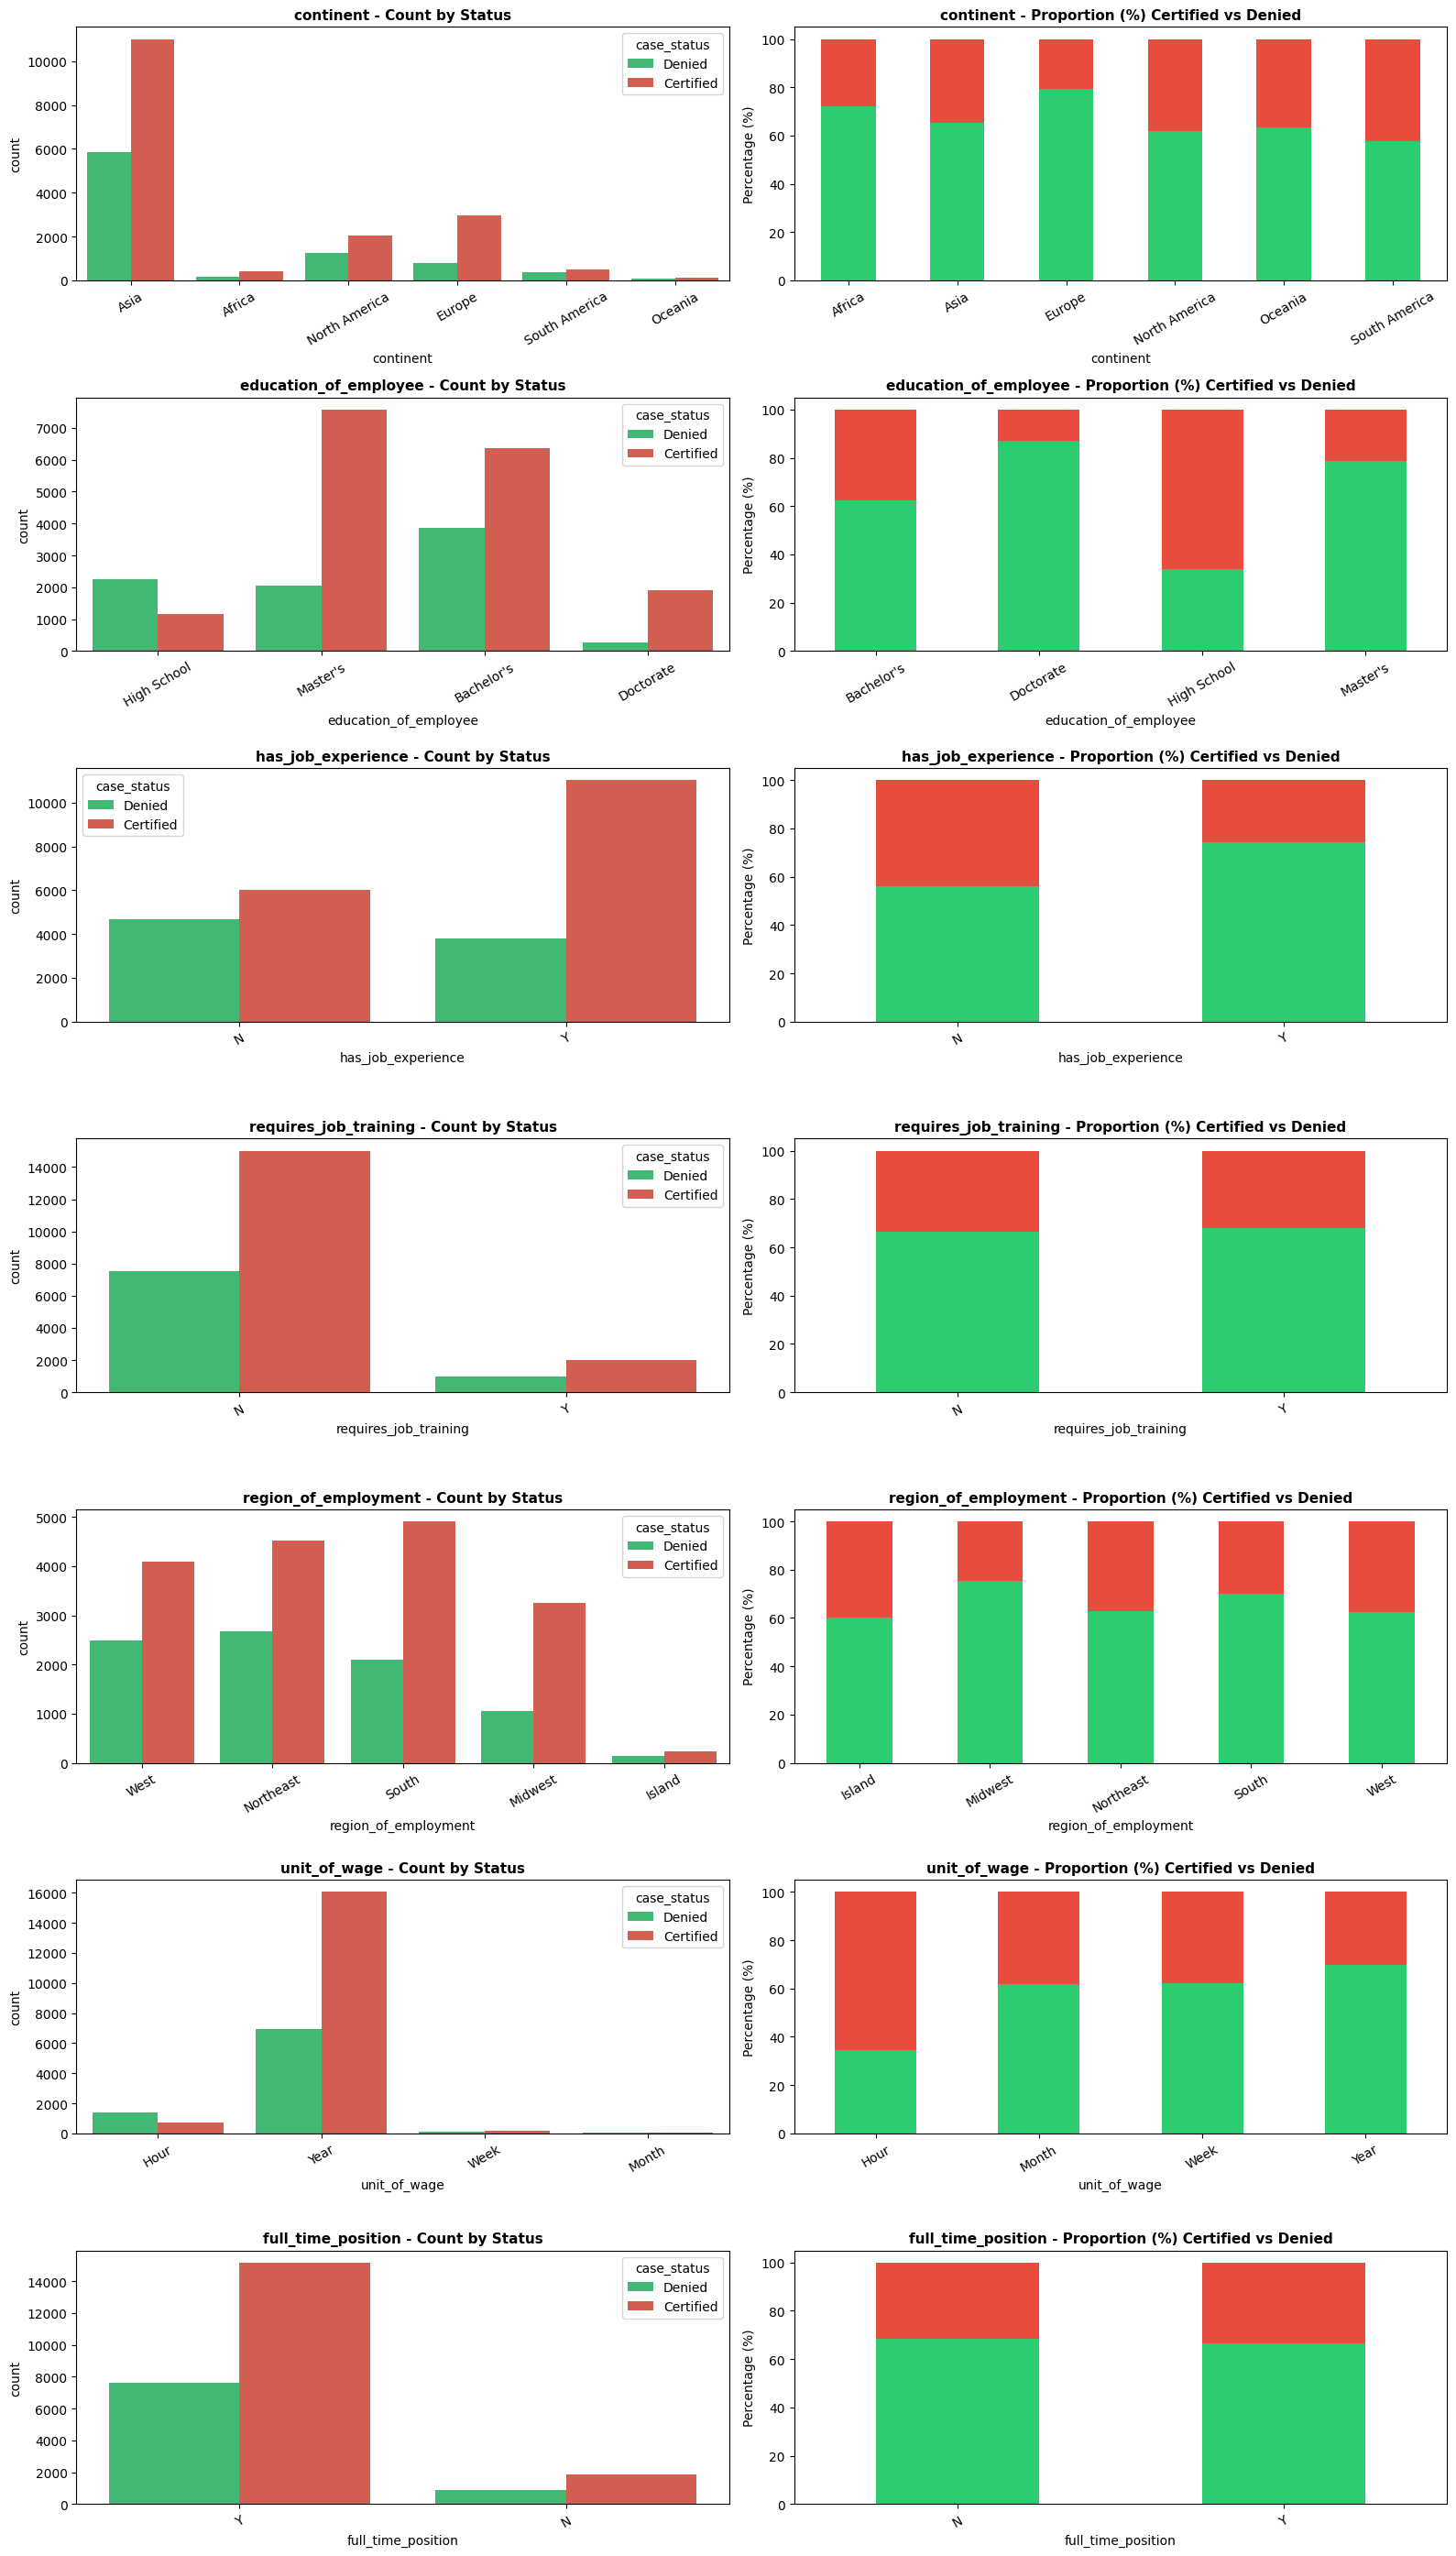

In [ ]:
# 3.4.1 Categorical Features vs Target: Approval Rates & Stacked Bar Charts
cat_cols = [col for col in categorical_features if col not in ["case_status", "case_id"]]

fig, axes = plt.subplots(len(cat_cols), 2, figsize=(16, 4 * len(cat_cols)))

for idx, col in enumerate(cat_cols):
    # 1. Cross-tabulation table (Percentage Certified per group)
    crosstab = pd.crosstab(df[col], df["case_status"], normalize="index") * 100
    
    # 2. Count plot grouped by Target
    sns.countplot(data=df, x=col, hue="case_status", ax=axes[idx, 0], palette=["#2ecc71", "#e74c3c"])
    axes[idx, 0].set_title(f"{col} - Count by Status", fontsize=11, fontweight="bold")
    axes[idx, 0].tick_params(axis="x", rotation=30)
    
    # 3. 100% Stacked Proportions (Shows True Approval Probability)
    crosstab.plot(kind="bar", stacked=True, ax=axes[idx, 1], color=["#2ecc71", "#e74c3c"], legend=False)
    axes[idx, 1].set_title(f"{col} - Proportion (%) Certified vs Denied", fontsize=11, fontweight="bold")
    axes[idx, 1].set_ylabel("Percentage (%)")
    axes[idx, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

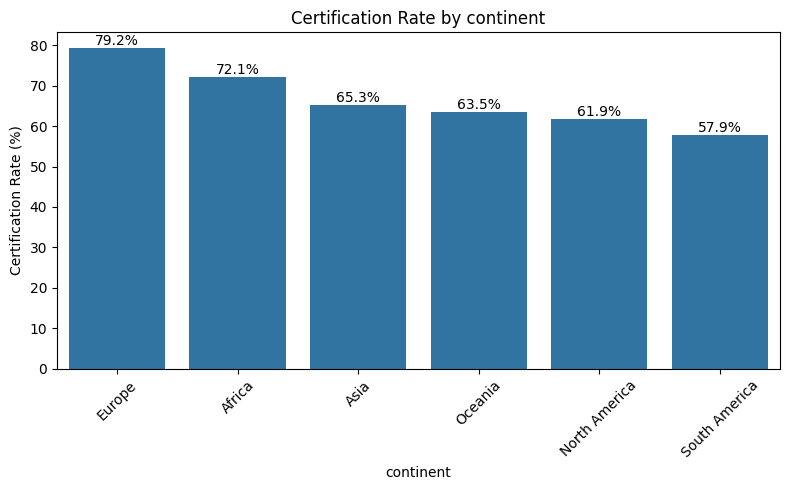

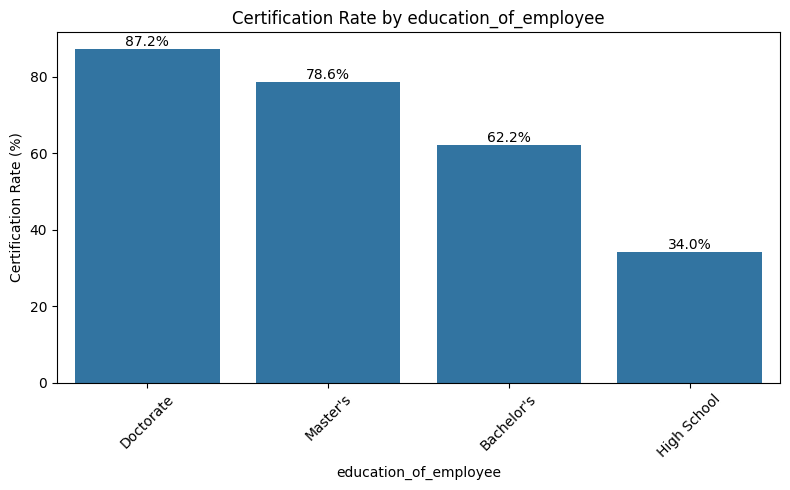

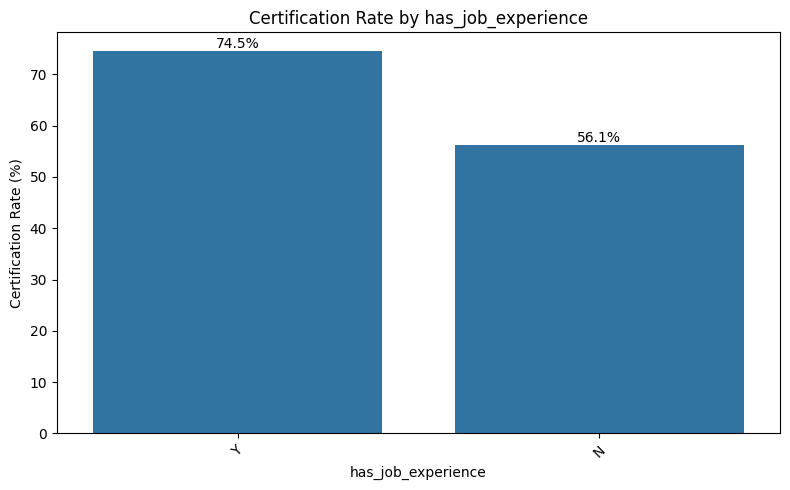

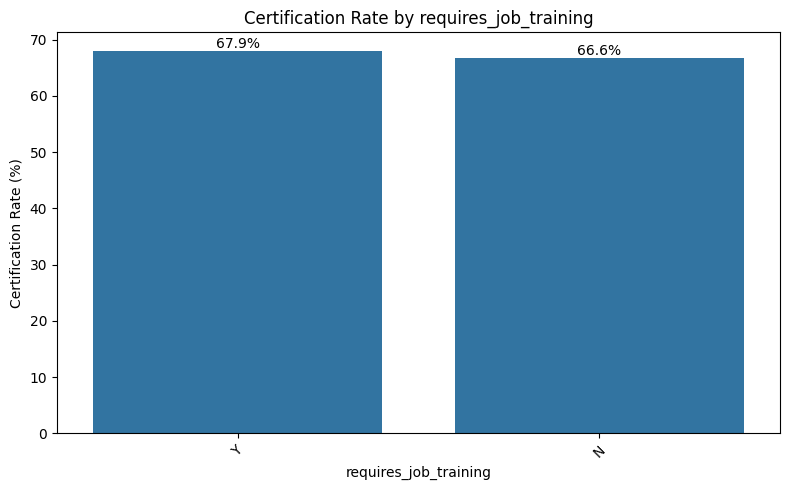

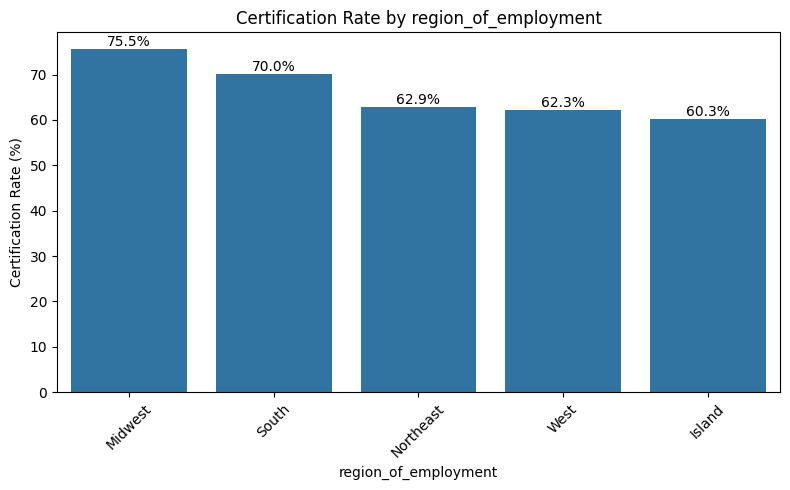

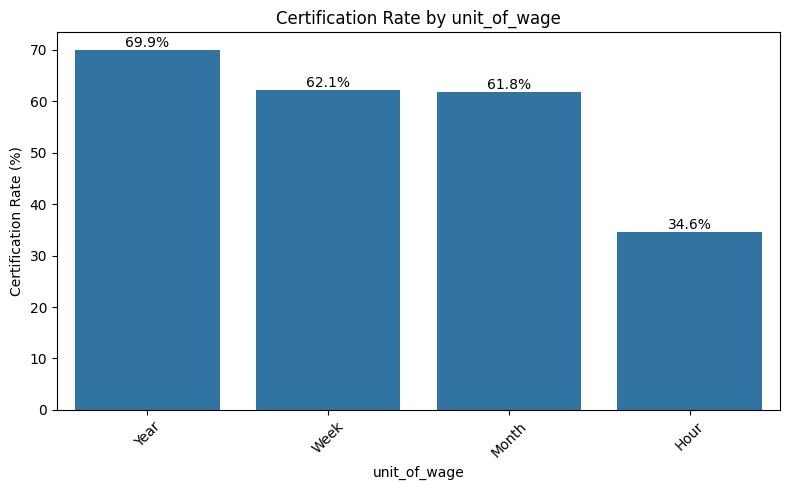

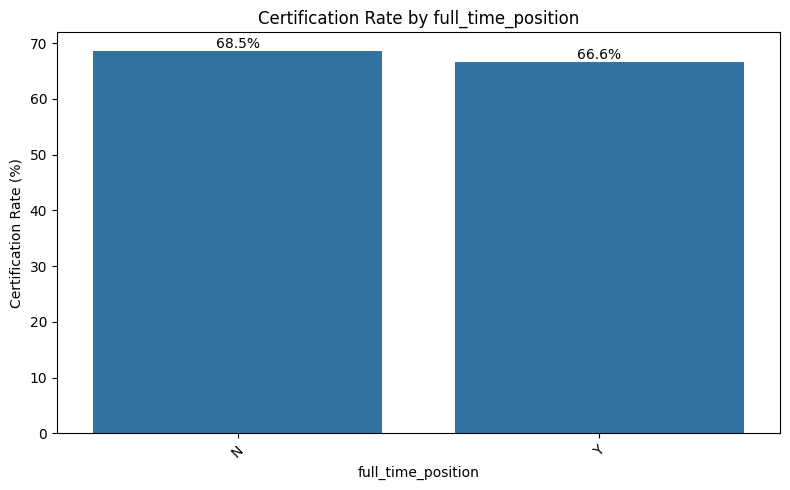

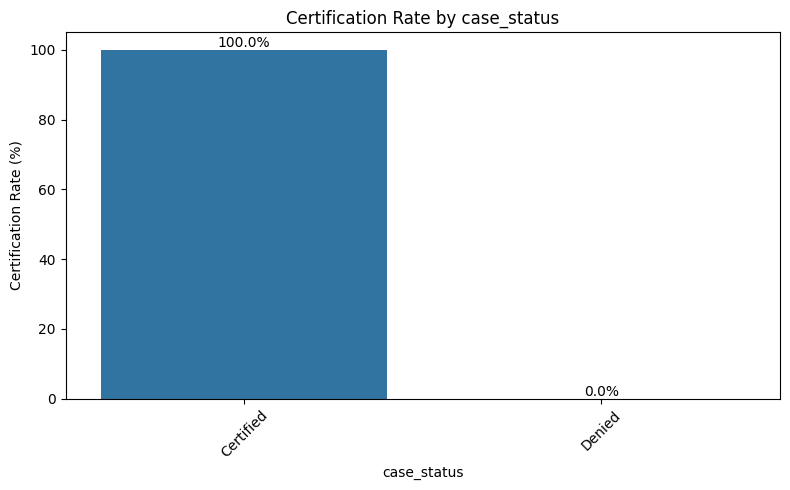

In [42]:
# Plot certification rate by categorical feature
for col in categorical_features:
    certification_rate = (
        df.groupby(col)["case_status"]
        .apply(lambda x: (x == "Certified").mean() * 100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        x=certification_rate.index,
        y=certification_rate.values
    )

    plt.title(f"Certification Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Certification Rate (%)")
    plt.xticks(rotation=45)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%"
        )

    plt.tight_layout()
    plt.show()

### 3.4.2 Numerical Features vs Target

In [45]:
# Compare numerical features across target classes
df.groupby("case_status")[numerical_features].agg(
    ["mean", "median", "std"]
).round(2)

no_of_employees                   yr_of_estab                 \
                       mean  median       std        mean  median    std   
case_status                                                                
Certified           5807.02  2147.0  23119.58     1979.67  1997.0  42.28   
Denied              5385.54  2032.5  22382.76     1978.89  1997.0  42.54   

            prevailing_wage                      
                       mean    median       std  
case_status                                      
Certified          77293.62  72486.27  52042.72  
Denied             68748.68  65431.46  53890.17

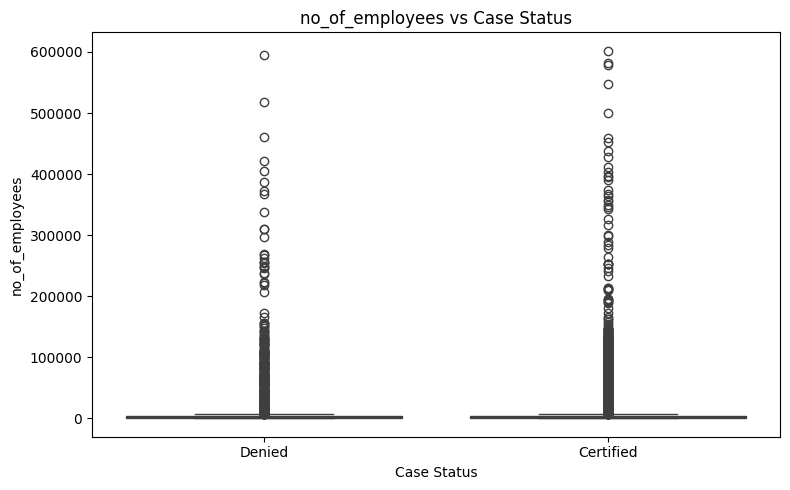

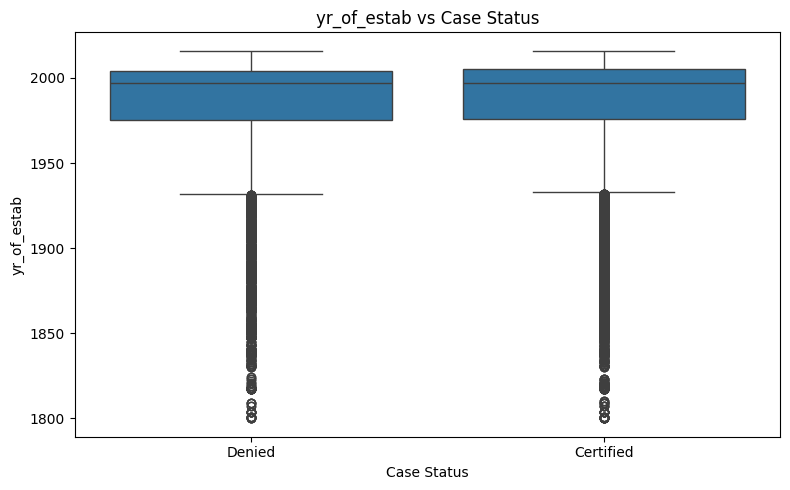

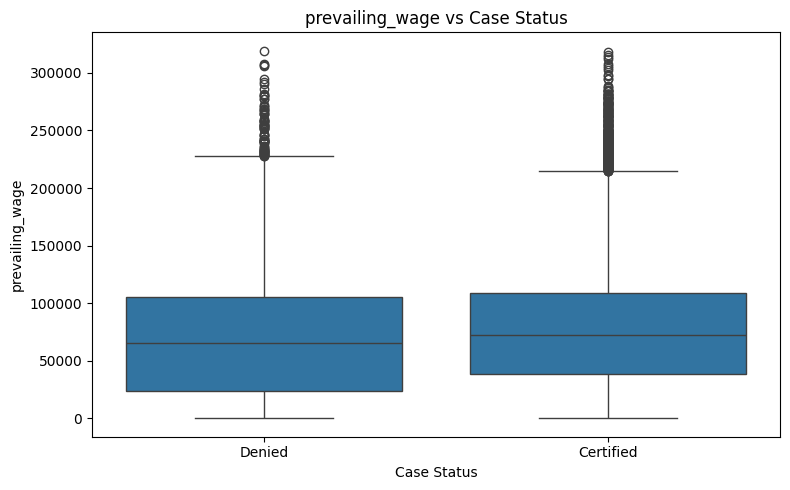

In [46]:
# Compare numerical features across visa status
for col in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="case_status",
        y=col
    )

    plt.title(f"{col} vs Case Status")
    plt.xlabel("Case Status")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

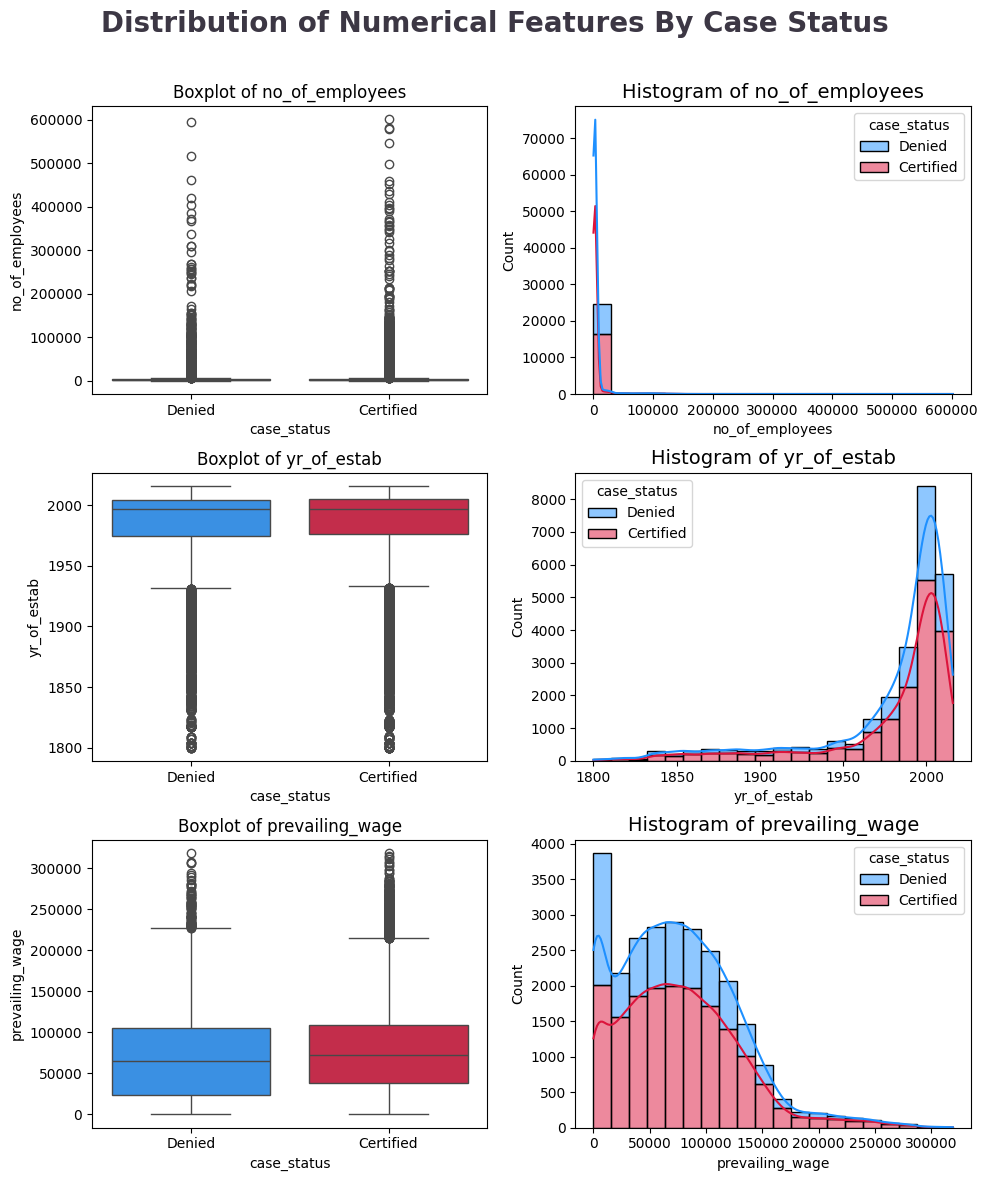

In [54]:
clr1 = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(3, 2, figsize=(10,12))
fig.suptitle('Distribution of Numerical Features By Case Status', color='#3C3744',
             fontsize=20, fontweight='bold', ha='center')
for i, col in enumerate(continues_features):   
    sns.boxplot(data=df, x='case_status', y=col,  palette=clr1, ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)
    sns.histplot(data=df, x=col, hue='case_status', bins=20, kde=True, 
                 multiple='stack', palette=clr1, ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.90)
# plt.savefig('images/multivariate_num.png')

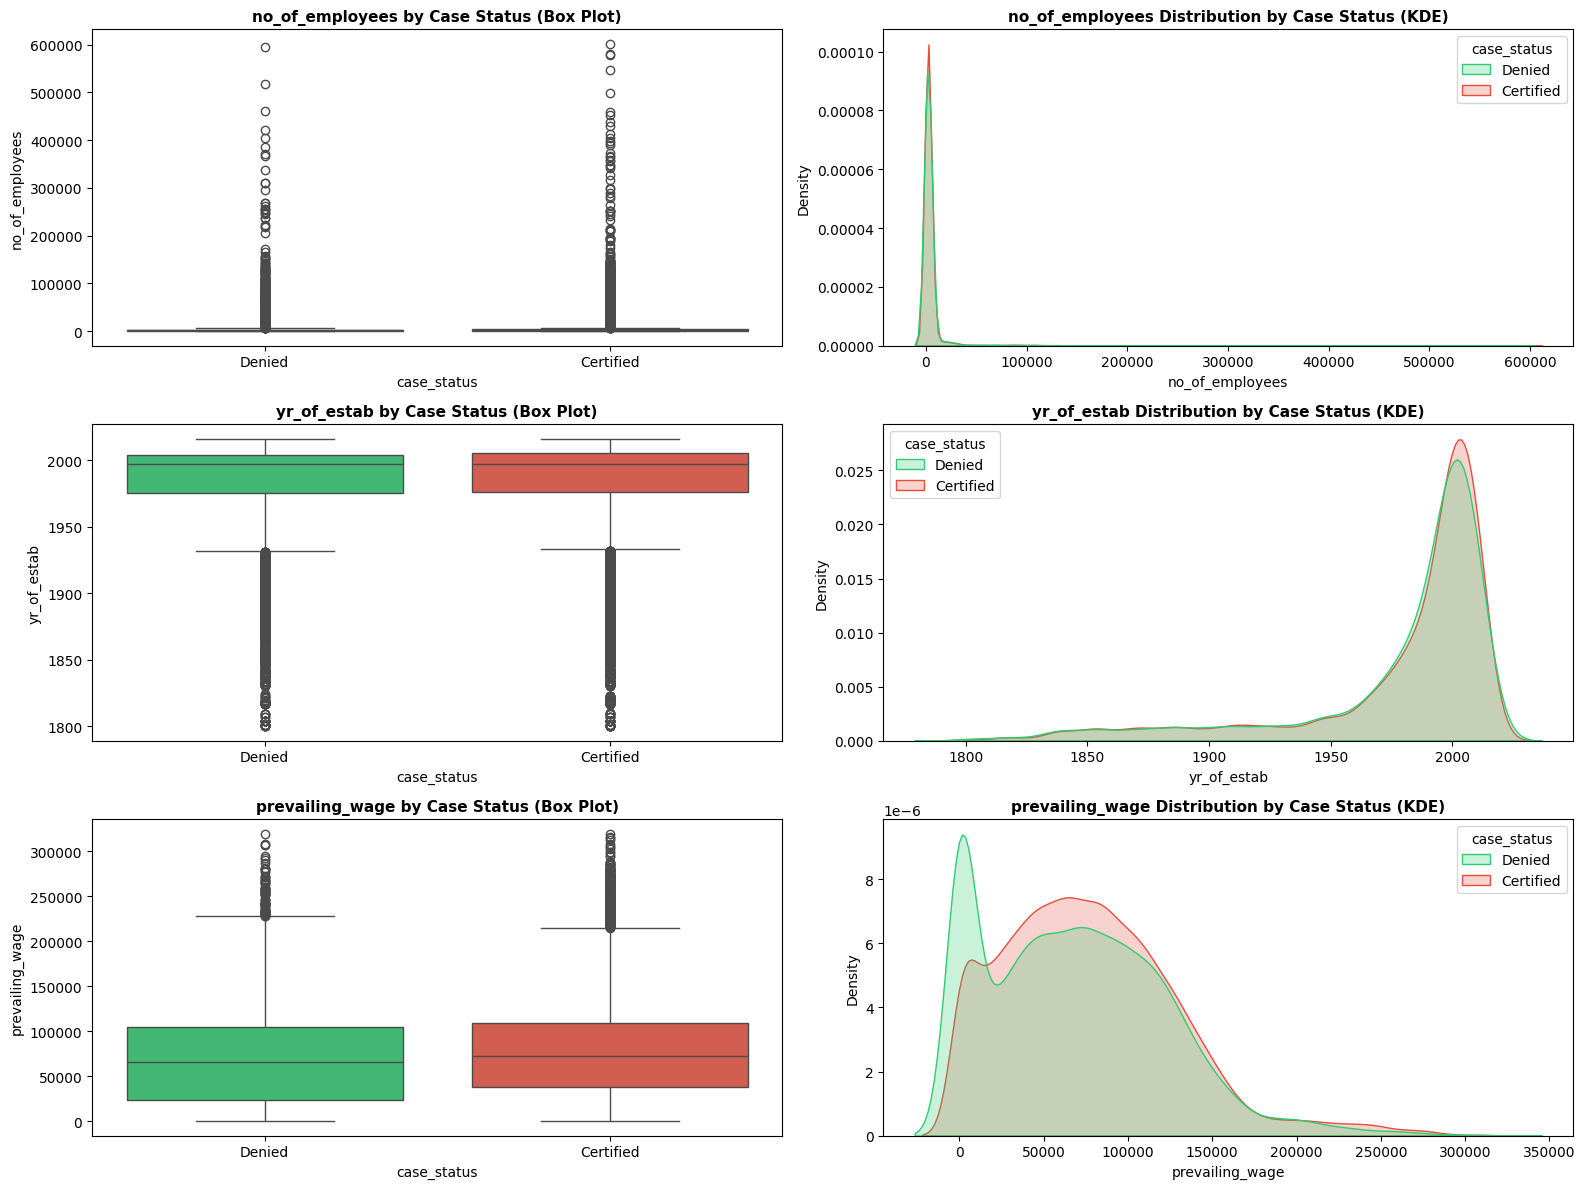

--- Numerical Feature Summary by Case Status ---


no_of_employees         yr_of_estab         prevailing_wage  \
                       mean  median        mean  median            mean   
case_status                                                               
Certified           5807.02  2147.0     1979.67  1997.0        77293.62   
Denied              5385.54  2032.5     1978.89  1997.0        68748.68   

                       
               median  
case_status            
Certified    72486.27  
Denied       65431.46

In [ ]:
# 3.4.2 Numerical Features vs Target: Box Plots & KDE Distributions
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(16, 4 * len(numeric_features)))

for idx, col in enumerate(numeric_features):
    # 1. Box Plot comparison
    sns.boxplot(data=df, x="case_status", y=col, ax=axes[idx, 0], palette=["#2ecc71", "#e74c3c"])
    axes[idx, 0].set_title(f"{col} by Case Status (Box Plot)", fontsize=11, fontweight="bold")
    
    # 2. KDE Distribution comparison
    sns.kdeplot(data=df, x=col, hue="case_status", ax=axes[idx, 1], palette=["#2ecc71", "#e74c3c"], fill=True, common_norm=False)
    axes[idx, 1].set_title(f"{col} Distribution by Case Status (KDE)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# Statistical comparison: Mean & Median by Case Status
print("--- Numerical Feature Summary by Case Status ---")
display(df.groupby("case_status")[numeric_features].agg(["mean", "median"]).round(2))

## Initial Analysis Report

* **No of Employees has many outliers which can be Handled in Feature Engineering and `no_of_employees` is Right Skewed.**

* **`yr_of_estab` is left skewed and some outliers below the lower bound of Box plot.**

* **`prevailing_wage` is right skewed with outliers above upper bound of box plot.**
* **There are No missing values in the dataset.**

* **The `case_id` column can be deleted because each row has unique values.**

* **The `case_status` column is the target to predict.**

* **In the Categorical column, features can be made Binary numerical in feature Encoding**

## 3.5) Multivariate Analysis

### 3.5.1 Numerical Feature Correlation

In [48]:
# Select numerical features
numerical_features = df.select_dtypes(
    exclude= "object"
).columns.tolist()

# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()

correlation_matrix

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


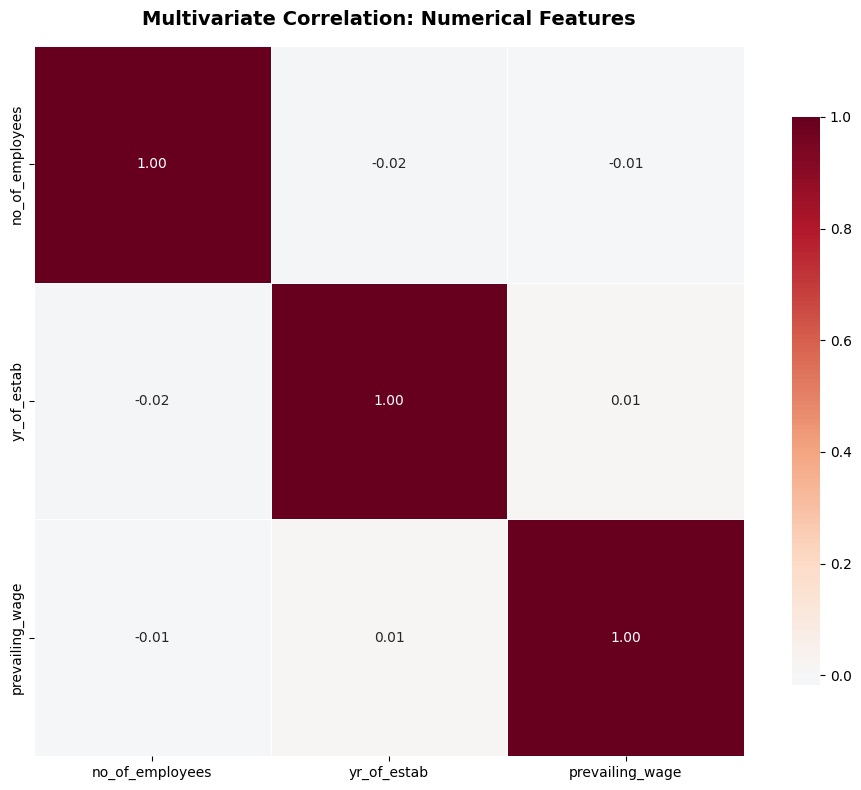

--- High Correlation Pairs (> |0.7|) ---
Series([], dtype: float64)


In [49]:
# 3.5.1 Correlation Matrix: Numerical Features
numeric_df = df.select_dtypes(exclude="object")

# Drop case_id if still present; keep only predictive numericals
if "case_id" in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=["case_id"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Multivariate Correlation: Numerical Features", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Highlight high correlations (absolute value > 0.7)
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1.0]  # Remove self-correlation
high_corr = high_corr[high_corr > 0.7]
print("--- High Correlation Pairs (> |0.7|) ---")
print(high_corr.round(2))

**Short Insight:**

- This reveals linear dependencies among predictors. If prevailing_wage and another feature share high correlation, one may be redundant—reducing dimensionality improves model stability and training speed.



**Multicollinearity & Feature-Target Correlation**

- what is 
    - Multivariate analysis means analyzing multiple variables together to understand relationships, dependencies, interactions, or patterns among them.


- Why "Multivariate" Matters in ML
    - In real life, visa approval is never decided by one factor alone. An officer considers education + experience + wage + company size + region together. Multivariate analysis captures these combined effects and interactions that univariate/bivariate analysis misses.


- What is Multicollinerity?
    - Multicollinearity occurs when two or more predictor features contain highly similar information.
    
    - in short, Multicollinearity analysis more than 3+ variables simultaneously.





In [50]:
# 3.5.2 Multicollinearity & Target Correlation
# Encode target temporarily for correlation check
df_temp = df.copy()
df_temp["case_status_encoded"] = df_temp["case_status"].map({"Certified": 1, "Denied": 0})

# Numerical vs Encoded Target
target_corr = numeric_df.apply(lambda x: x.corr(df_temp["case_status_encoded"]))
print("--- Feature-Target Correlation (Numerical) ---")
print(target_corr.sort_values(ascending=False).round(3))

# Variance Inflation Factor (VIF) Approximation using R²
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) for i in range(len(numeric_df.columns))]

print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data.sort_values("VIF", ascending=False).round(2))

--- Feature-Target Correlation (Numerical) ---
prevailing_wage    0.076
no_of_employees    0.009
yr_of_estab        0.009
dtype: float64

--- Variance Inflation Factor (VIF) ---
           Feature   VIF
1      yr_of_estab  3.05
2  prevailing_wage  2.99
0  no_of_employees  1.06


- Short Insight:

- VIF > 10 indicates severe multicollinearity (e.g., if yr_of_estab and no_of_employees both scale with company size). Features with high VIF should be removed or combined (e.g., create company_age instead of raw yr_of_estab combined with size proxies) before training linear models.



* Multivariate analysis is the analysis of more than one variable.

### Check Multicollinearity in Numerical features

**Discrete vs Continuous Split**

In [56]:
discrete_features = [
    feature for feature in numeric_features
    if len(df[feature].unique()) <= 25
]

continuous_features = [
    feature for feature in numeric_features
    if len(df[feature].unique()) > 25
]

print(
    'We have {} discrete features : {}'.format(
        len(discrete_features),
        discrete_features
    )
)

print(
    '\nWe have {} continuous_features : {}'.format(
        len(continuous_features),
        continuous_features
    )
)

We have 0 discrete features : []

We have 3 continuous_features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


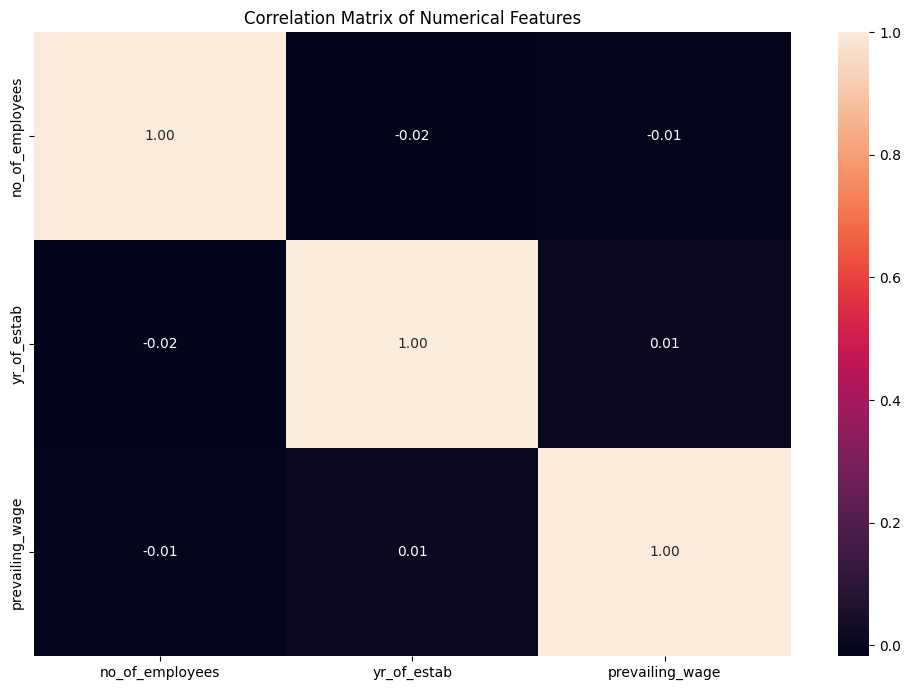

In [58]:
# Calculate correlation among numerical features
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [57]:
# Identify highly correlated numerical feature pairs
correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

correlation_pairs[
    correlation_pairs.abs() >= 0.70
]

Series([], dtype: float64)

### Check Multicollinearity for Categorical features

* **A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test**

* **A chi-square statistic is one way to show a relationship between two categorical variables.**

* **Here we test correlation of Categorical columns with Target column i.e case_status**

- Null Hypothesis ($ H_0 $): The Feature is independent of target column (No-Correlation)

- Alternative Hypothesis ($ H_1 $): The Feature and Target column are not independent (Correalted)

In [59]:
from scipy.stats import chi2_contingency

chi2_test = []

for feature in categorical_features:

    if chi2_contingency(
        pd.crosstab(
            df['case_status'],
            df[feature]
        )
    )[1] < 0.05:

        chi2_test.append('Reject Null Hypothesis')

    else:
        chi2_test.append('Fail to Reject Null Hypothesis')

result = pd.DataFrame(
    data=[categorical_features, chi2_test]
).T

result.columns = [
    'Column',
    'Hypothesis Result'
]

result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


**Report** 
* Here `requires_job_training` fails to Rejects Null Hypothesis which means it doesn't correlate with target column.

In [55]:
from scipy.stats import chi2_contingency

chi2_results = []

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df[feature],
        df["case_status"]
    )

    chi2_stat, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    chi2_results.append({
        "Feature": feature,
        "Chi2 Statistic": chi2_stat,
        "P-Value": p_value,
        "Degrees of Freedom": dof,
        "Significant": p_value < 0.05
    })

chi2_results = pd.DataFrame(chi2_results)

chi2_results = chi2_results.sort_values(
    by="P-Value"
)

chi2_results

,Feature,Chi2 Statistic,P-Value,Degrees of Freedom,Significant
1,education_of_employee,2772.207275,0.000000e+00,3,True
7,case_status,25475.491853,0.000000e+00,1,True
5,unit_of_wage,1108.507062,5.193385e-240,3,True
2,has_job_experience,940.058096,1.922560e-206,1,True
0,continent,351.380408,8.828798e-74,5,True
4,region_of_employment,298.450836,2.338664e-63,4,True
6,full_time_position,4.029932,4.469975e-02,1,True
3,requires_job_training,1.752484,1.855647e-01,1,False


In [61]:
from scipy.stats import chi2_contingency

chi2_results = []

n = len(df)

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df[feature],
        df["case_status"]
    )

    chi2_stat, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    r, k = contingency_table.shape

    cramers_v = np.sqrt(
        chi2_stat /
        (n * min(k - 1, r - 1))
    )

    chi2_results.append({
        "Feature": feature,
        "Chi2": round(chi2_stat, 3),
        "P-Value": p_value,
        "Cramers_V": round(cramers_v, 3),
        "Significant": p_value < 0.05
    })

chi2_results = pd.DataFrame(chi2_results)

chi2_results.sort_values(
    by="Cramers_V",
    ascending=False
)

,Feature,Chi2,P-Value,Cramers_V,Significant
7,case_status,25475.492,0.000000e+00,1.000,True
1,education_of_employee,2772.207,0.000000e+00,0.330,True
5,unit_of_wage,1108.507,5.193385e-240,0.209,True
2,has_job_experience,940.058,1.922560e-206,0.192,True
0,continent,351.380,8.828798e-74,0.117,True
4,region_of_employment,298.451,2.338664e-63,0.108,True
6,full_time_position,4.030,4.469975e-02,0.013,True
3,requires_job_training,1.752,1.855647e-01,0.008,False


### Group By Operation

### 4.2 Does applicant Continent has any impact on Visa status ?

In [ ]:
#group data by continent and their count of case_status
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

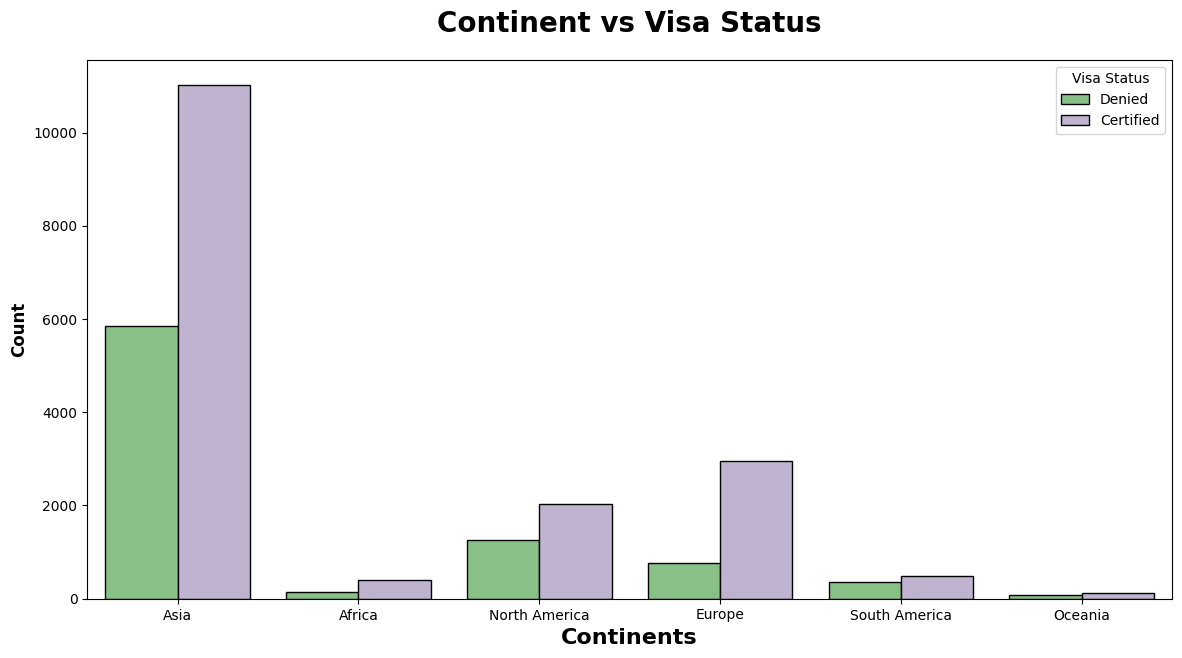

In [ ]:
plt.subplots(figsize=(14,7))
sns.countplot(x="continent",hue="case_status", data=df, ec = "black",palette="Accent")
plt.title("Continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Continents", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

In [ ]:
df2 = df.copy()

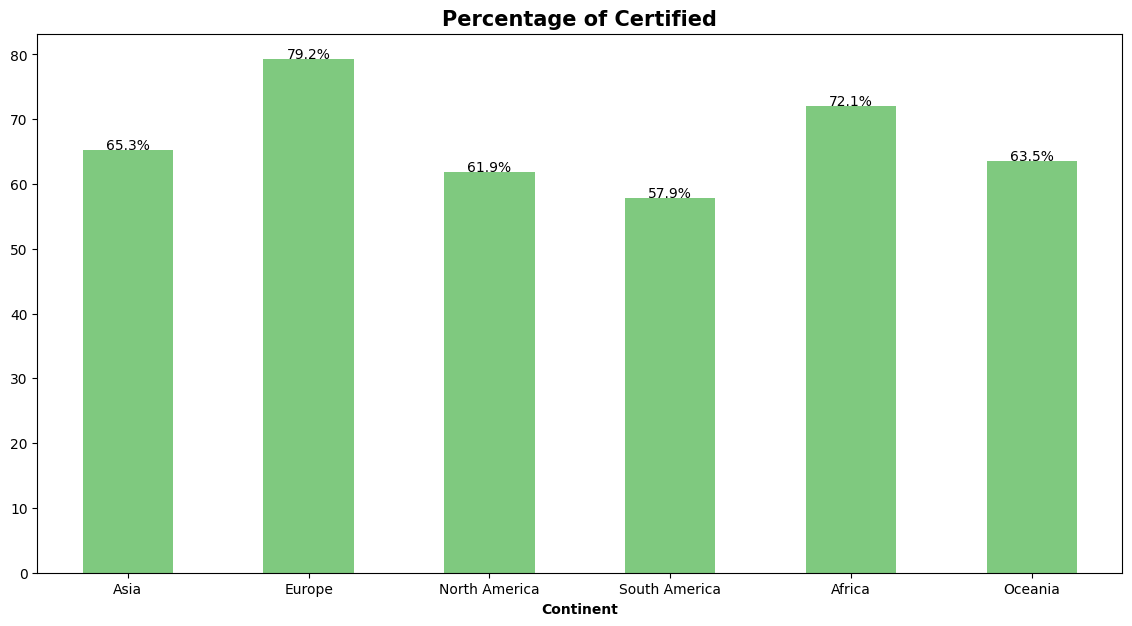

In [ ]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('Continent' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report:**
* As per the Chart Asia applicants applied more than other continents.
* 43% of Certified applications are from Asia.
* This is followed by Europe with 11% of Certified applications.
* Highest chance of getting certified if you are from `Europe` and followed by `Africa`

### 4.3 Does applicant education has any impact on Visa status ?

In [ ]:
#group data by Education and their count of case_status
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

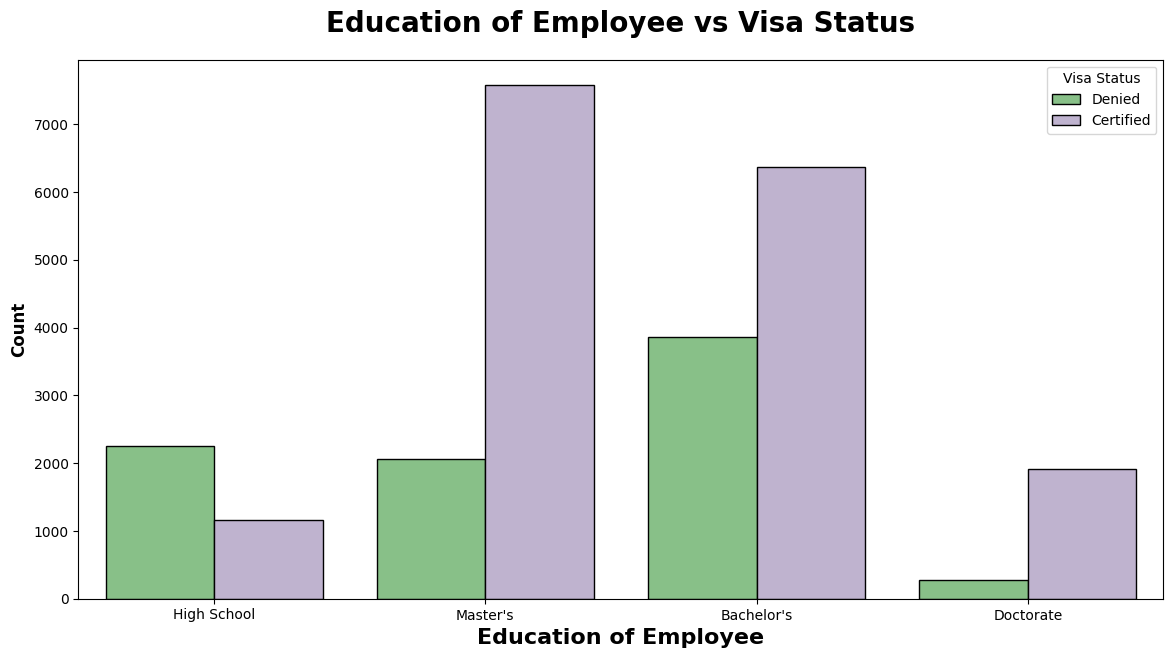

In [ ]:
plt.subplots(figsize=(14,7))
sns.countplot(x="education_of_employee",hue="case_status", data=df, ec = "black",palette="Accent")
plt.title("Education of Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Education of Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

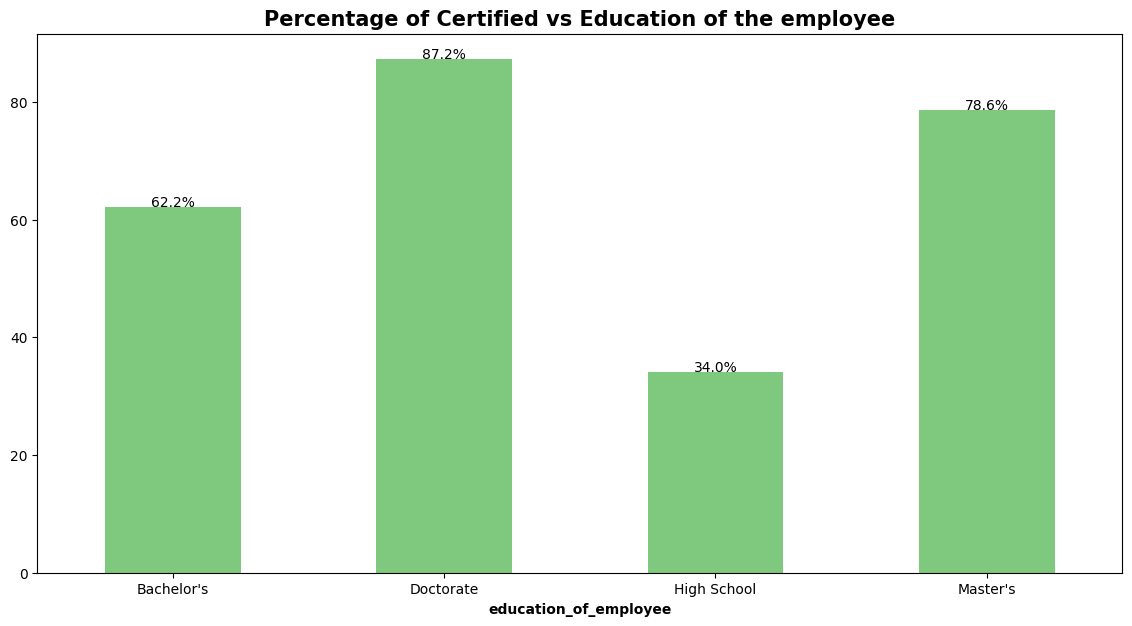

In [ ]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs Education of the employee" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('education_of_employee' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Insights**
- education status has high impact
- `Doctorate` and `Master's` graduates have higher cange of being accepted then the others.

### 4.4 Does applicant's previous work experience has any impact on Visa status ?

In [ ]:
#group data by has_job_experience and count case_status
df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

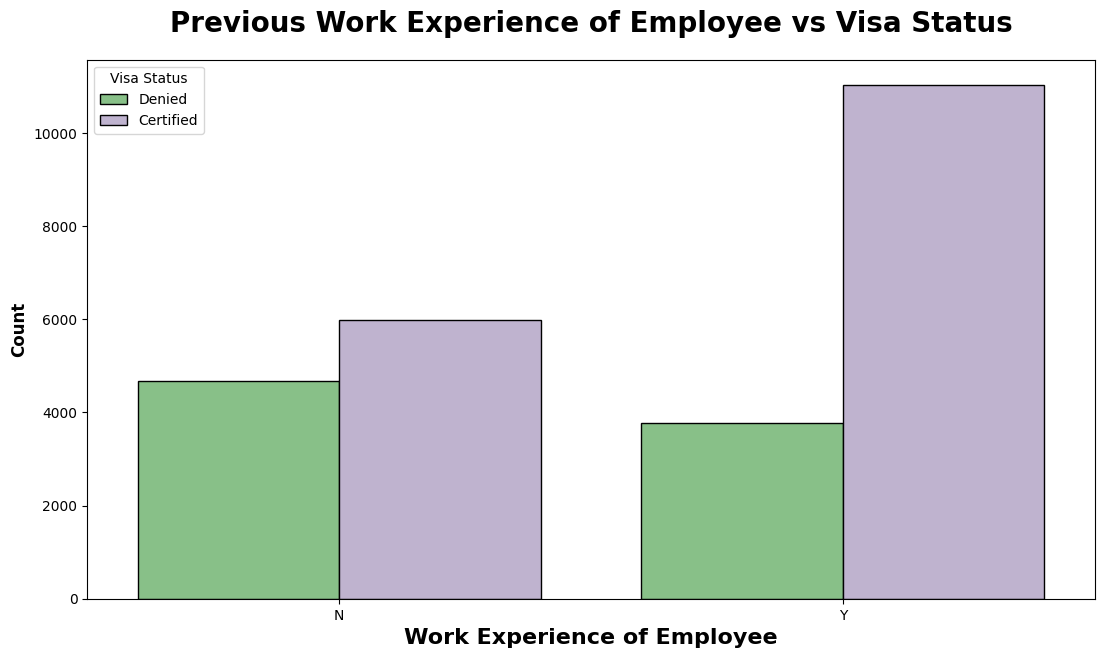

In [ ]:
plt.subplots(figsize=(13,7))
sns.countplot(x="has_job_experience",hue="case_status", data=df, ec= "black",palette="Accent")
plt.title("Previous Work Experience of Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Work Experience of Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

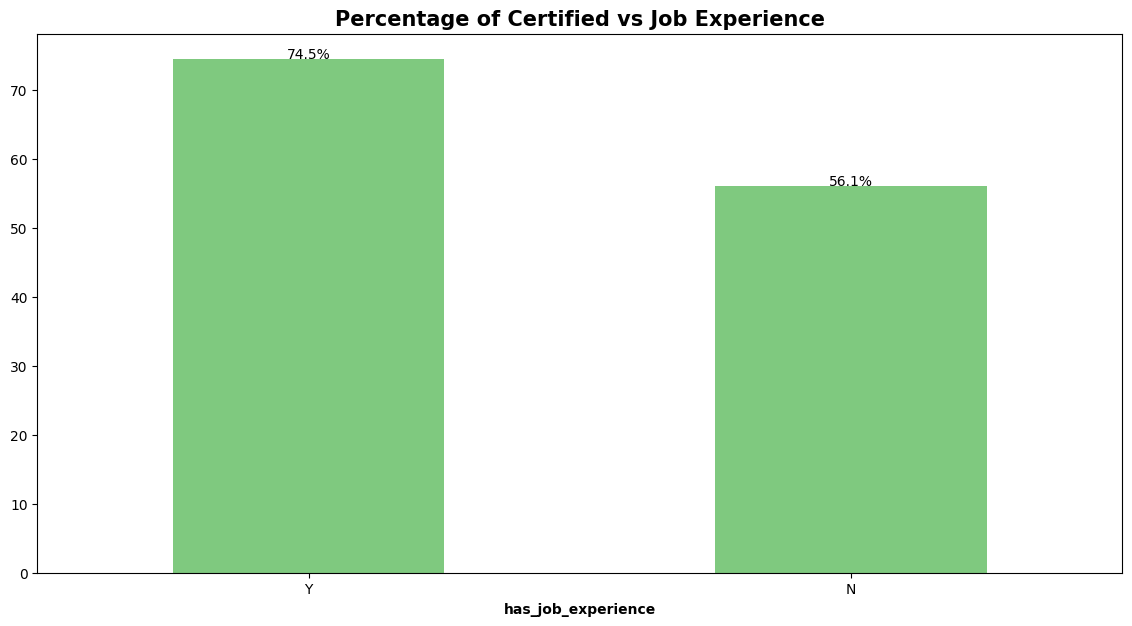

In [ ]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs Job Experience" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('has_job_experience' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report**
* People with previous work experience has been certified 74.5% only 25.5% applicant has been denied.
* People with No previous work experience has been certified 56% and denied 43%.
* This means work experience has effect on Visa status.
* There is a slight edge for the people with work experiences then the fresheres as expected. But the difference is not huge.

### 4.5 If the Employee requires job training, does it make any impact on visa status?

In [ ]:
#group data by requires_job_training and count case_status
df.groupby('requires_job_training')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

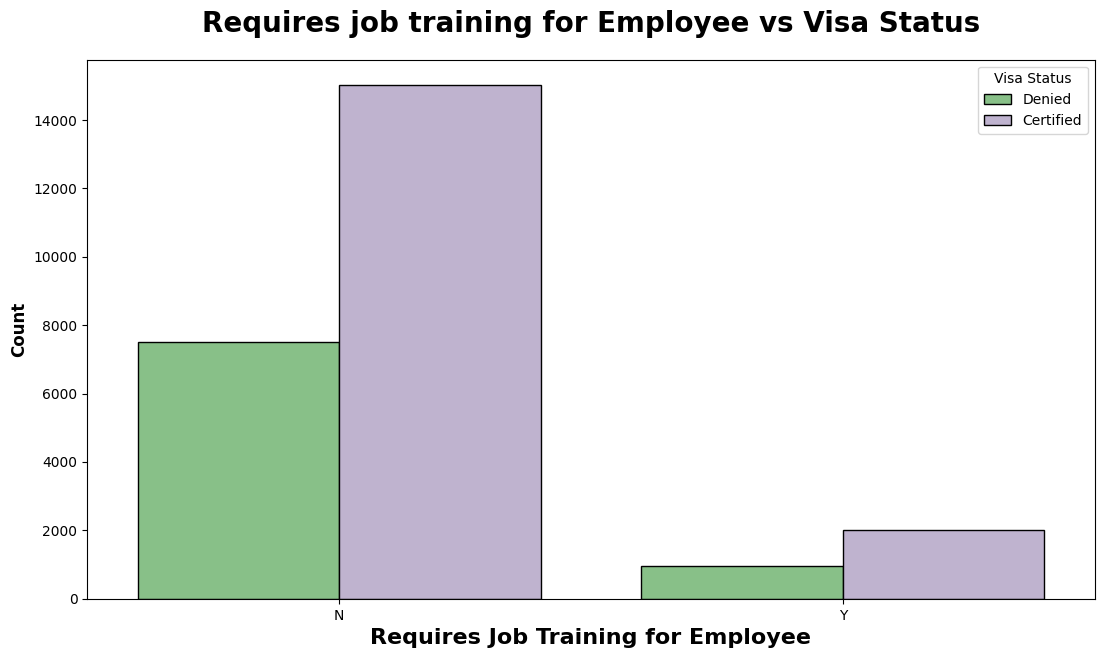

In [ ]:
plt.subplots(figsize=(13,7))
sns.countplot(x="requires_job_training",hue="case_status", data=df, ec= "black",palette="Accent")
plt.title("Requires job training for Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

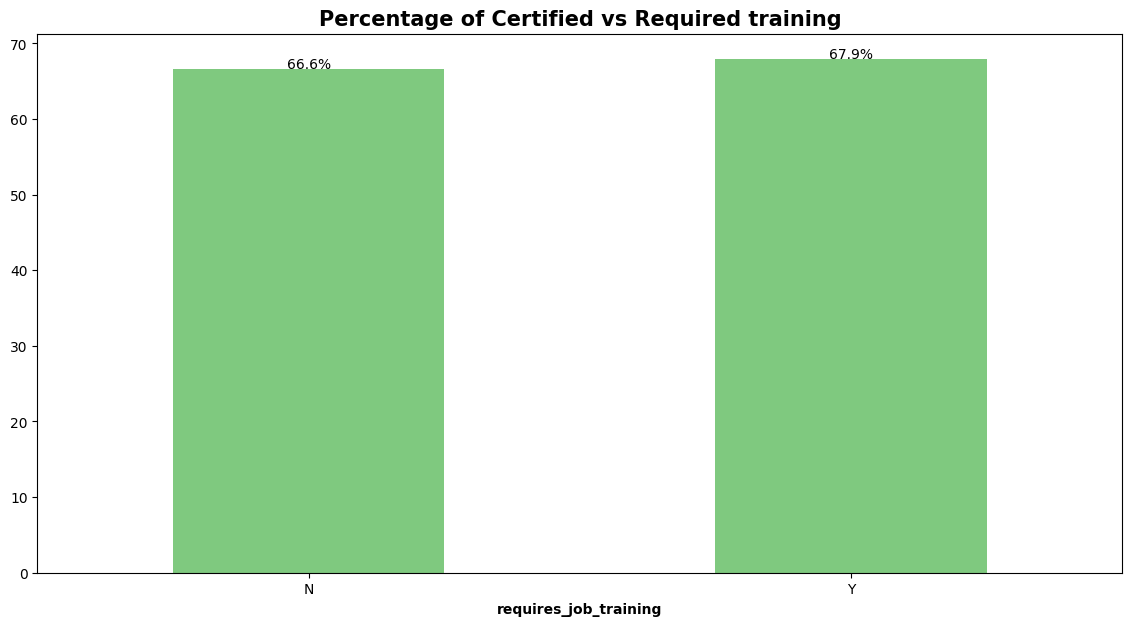

In [ ]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['requires_job_training'].value_counts()/df2['requires_job_training'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs Required training" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['requires_job_training'].value_counts()/df2['requires_job_training'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('requires_job_training' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report**
* If employee requires job training and it doesn't have any effect on Visa status.
* 88% of applicant don't require job training. 
* 63% of people who doesnt want job training got certified.
* For employees who require job training 67% of people get certified.
* As we checked in Chi-Squared test this feature doesn't have much impact on target variable, which is confirmed by above plot.

### 4.6 Does Number of employees of employer has any impact on Visa status?

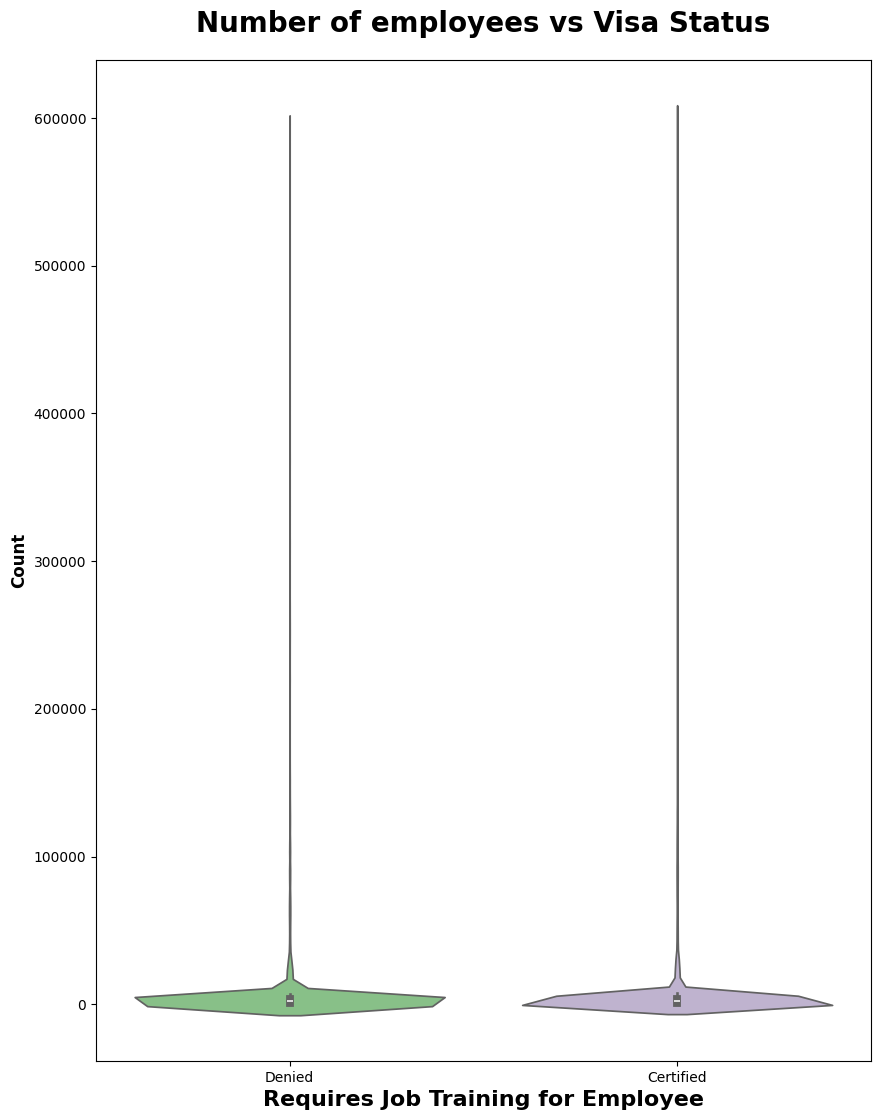

In [ ]:
plt.subplots(figsize=(10,13))
sns.violinplot(x="case_status",y='no_of_employees', data=df, palette="Accent")
plt.title("Number of employees vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.ylim()
plt.show()

**Insights**
 - The distrubution of both is similar. But there are outliers in both the classes which need to be handeled.

### 4.7 Wages and its impact on Visa status

In [ ]:
#group data by unit_of_wage and count the case_status
df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True)

unit_of_wage  case_status
Hour          Denied         0.653686
              Certified      0.346314
Month         Certified      0.617978
              Denied         0.382022
Week          Certified      0.621324
              Denied         0.378676
Year          Certified      0.698850
              Denied         0.301150
Name: proportion, dtype: float64

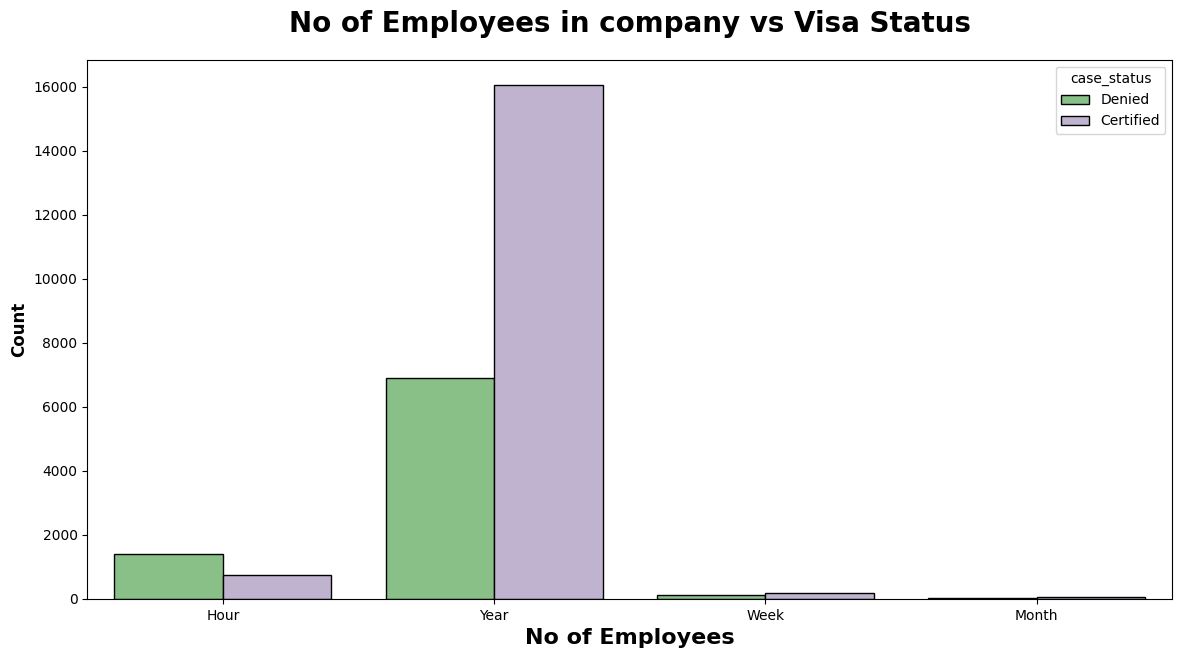

In [ ]:
plt.subplots(figsize=(14,7))
sns.countplot(x="unit_of_wage",hue="case_status", data=df,ec='k', palette='Accent')
plt.title("No of Employees in company vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("No of Employees", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

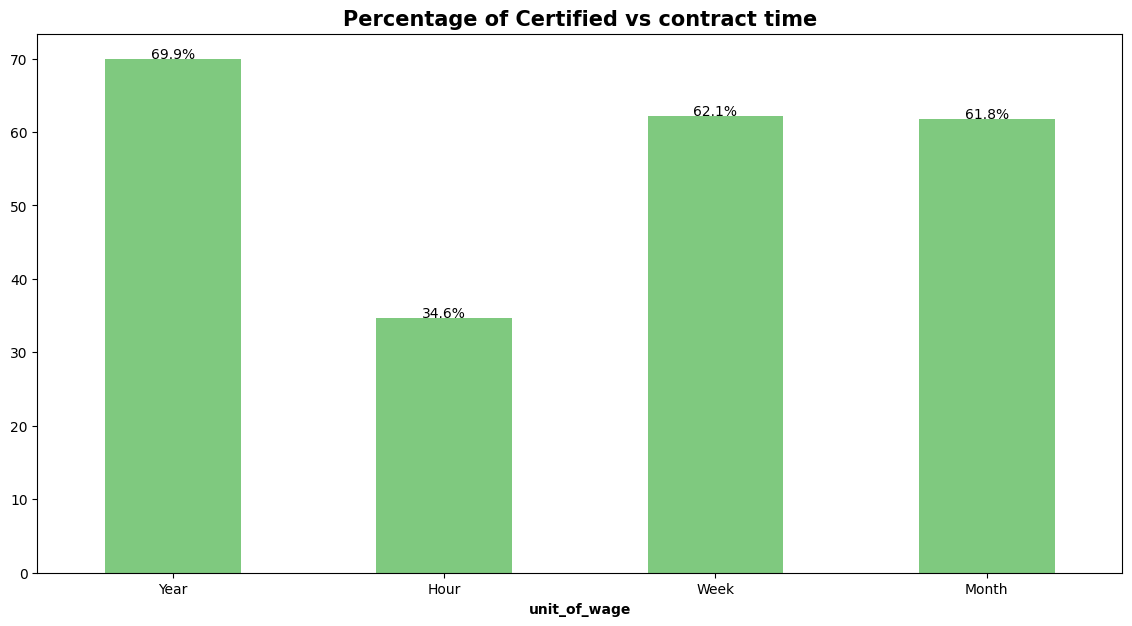

In [ ]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['unit_of_wage'].value_counts()/df2['unit_of_wage'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs contract time" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['unit_of_wage'].value_counts()/df2['unit_of_wage'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('unit_of_wage' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report**
* For employees who applied for hourly pay 65% of them were denied.
* Yearly unit wage application were accepted for 69% and denied for 31% of the time.
* There is a higher chance of yearly contract than other and immediately followed by week and month.

### 4.7 Does Region of employment has impact on Visa status ?

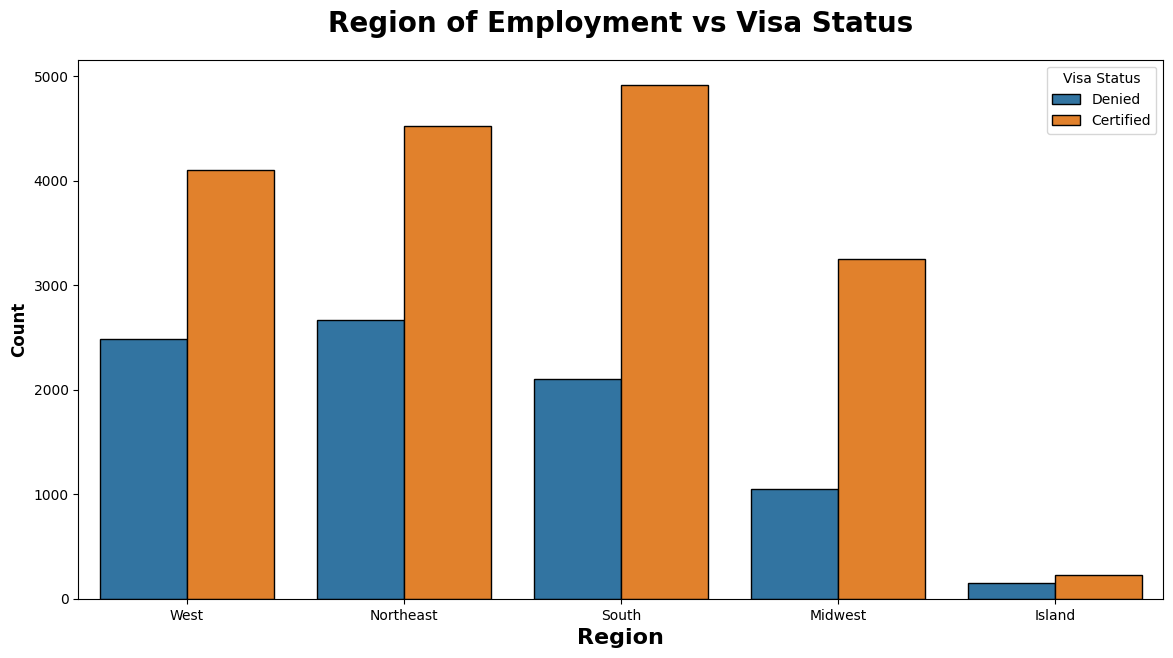

In [ ]:
plt.subplots(figsize=(14,7))
sns.countplot(x="region_of_employment",hue="case_status", data=df,ec='k')
plt.title("Region of Employment vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

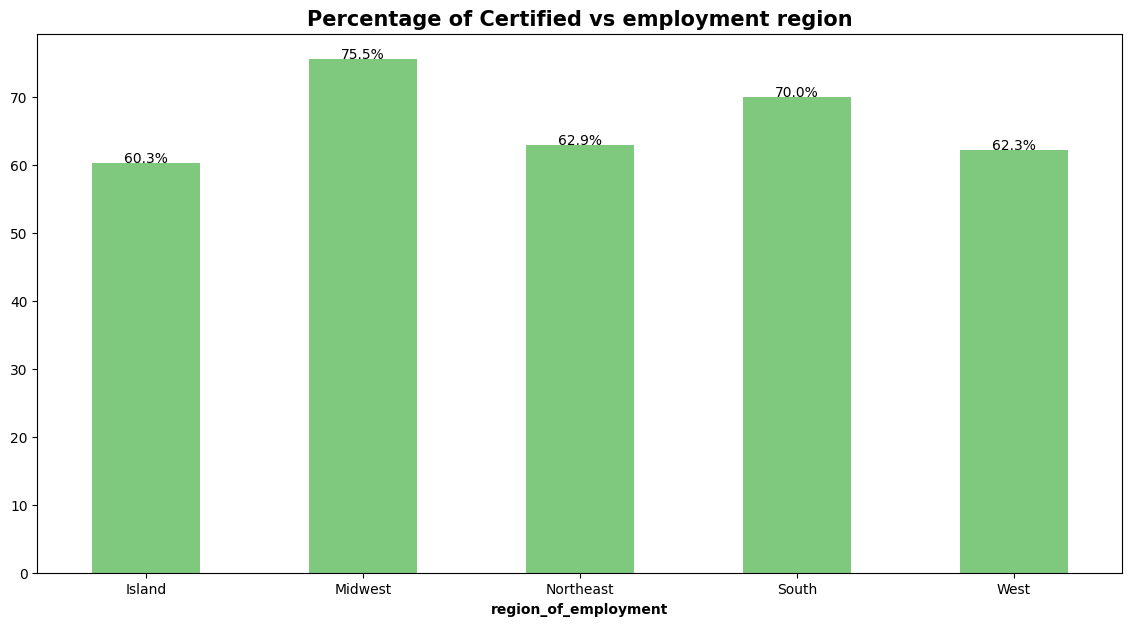

In [ ]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['region_of_employment'].value_counts()/df2['region_of_employment'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs employment region" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['region_of_employment'].value_counts()/df2['region_of_employment'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('region_of_employment' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report** 
* As per chart all the region have very similar pattern of getting Visa certified and Denied.
* There is a slight edge for `midwest` followed by `South` region

### 4.8 Does Prevailing wage has any impact on Visa status ?

In [ ]:
df.groupby('prevailing_wage').case_status.value_counts()

prevailing_wage  case_status
2.1367           Certified      1
2.9561           Denied         1
3.0031           Denied         1
3.3188           Denied         1
3.4889           Certified      1
                               ..
311734.4900      Certified      1
314156.0600      Certified      1
315497.6000      Certified      1
318446.0500      Certified      1
319210.2700      Denied         1
Name: count, Length: 25462, dtype: int64

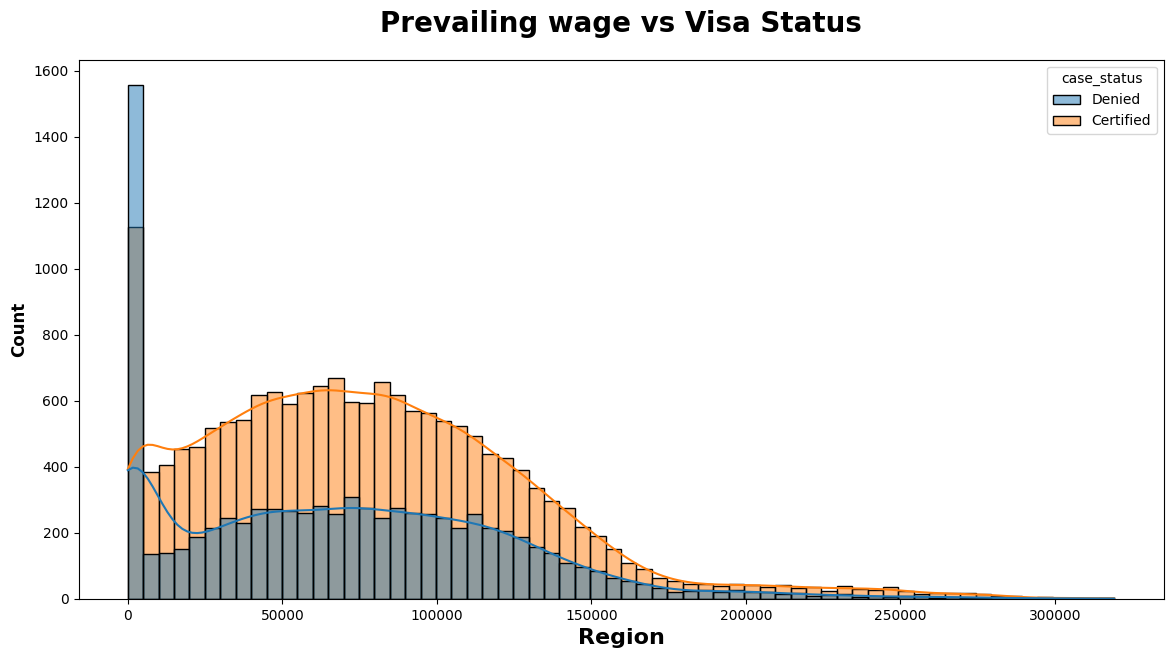

In [ ]:
plt.subplots(figsize=(14,7))
sns.histplot(x="prevailing_wage",hue="case_status", data=df, kde=True)
plt.title("Prevailing wage vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

**Insights**
 - The distribution of both the classes are same but need to handel the outliers.

#### 4.8.1 Prevailing wage based on Education

In [ ]:
print('Average Prevailing wage based on Employee education')
df.groupby('education_of_employee')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Employee education


,prevailing_wage
education_of_employee,
Master's,78843.057843
Bachelor's,73405.443735
High School,71582.147756
Doctorate,64561.076657


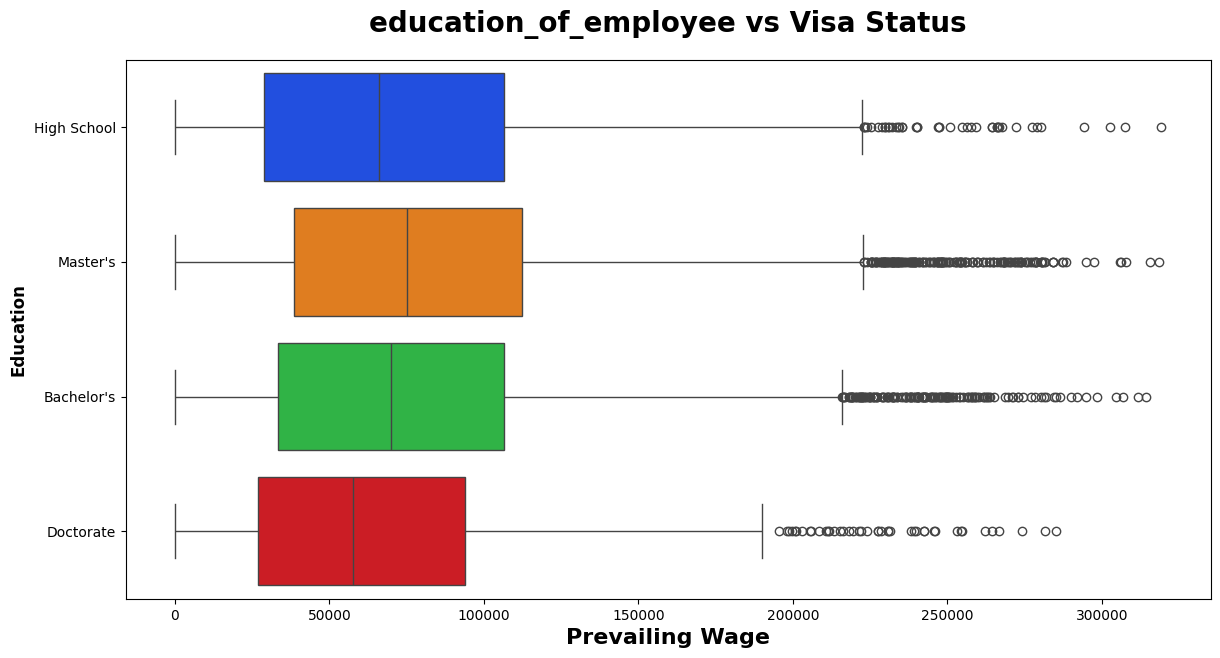

In [ ]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="education_of_employee",x = "prevailing_wage", data=df,palette='bright')
plt.title("education_of_employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("Education", weight="bold", fontsize=12)
plt.show()

**Report**
* Based on the above table and charts its seen that applicant with Master's education has higher average prevailing wages.
* Master's education applicants have median salary of $78.8k, which approximately 20% higher than Doctrate's average wage, which is strange.

#### 4.8.2 Prevailing wage based on Job experience

In [ ]:
print('Median Prevailing wage based on Job experience')
df.groupby('has_job_experience')['prevailing_wage'].median().to_frame().sort_values(by='prevailing_wage',ascending=False)

Median Prevailing wage based on Job experience


,prevailing_wage
has_job_experience,
N,72602.290
Y,69033.665


**Report**
* Suprisingly people who has less job experience has more prevailing wage.
* No job experience applicant has median prevailing wage as 72k USD.
* Previous job experience applicant has median prevailing wage as 69K USD.

#### 4.8.3 Prevailing wage based on Continent

In [ ]:
print('Average Prevailing wage based on Continent')
df.groupby('continent')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Continent


,prevailing_wage
continent,
Asia,79543.021780
Africa,77425.923450
Oceania,75994.276719
North America,68066.319257
South America,60209.575314
Europe,59842.925899


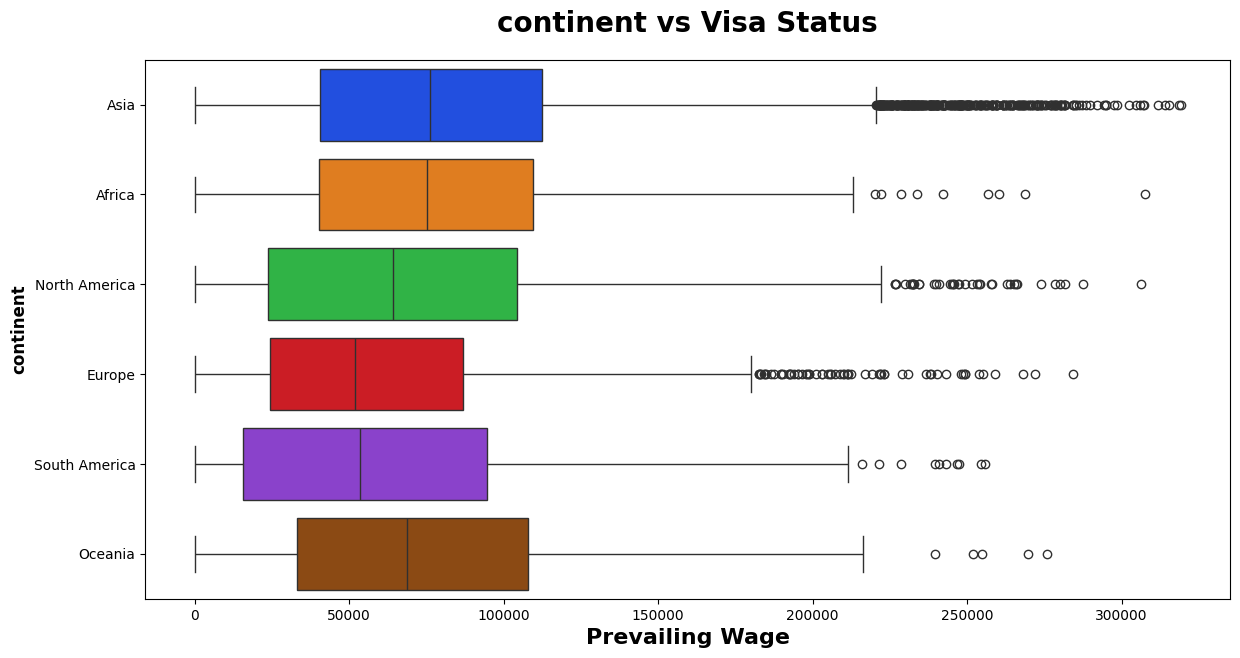

In [ ]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="continent",x = "prevailing_wage", data=df,palette='bright')
plt.title("continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("continent", weight="bold", fontsize=12)
plt.show()

**Report**
* Average salary of people from Asia is higher than other continents.

### 4.9 Year of Establishment 

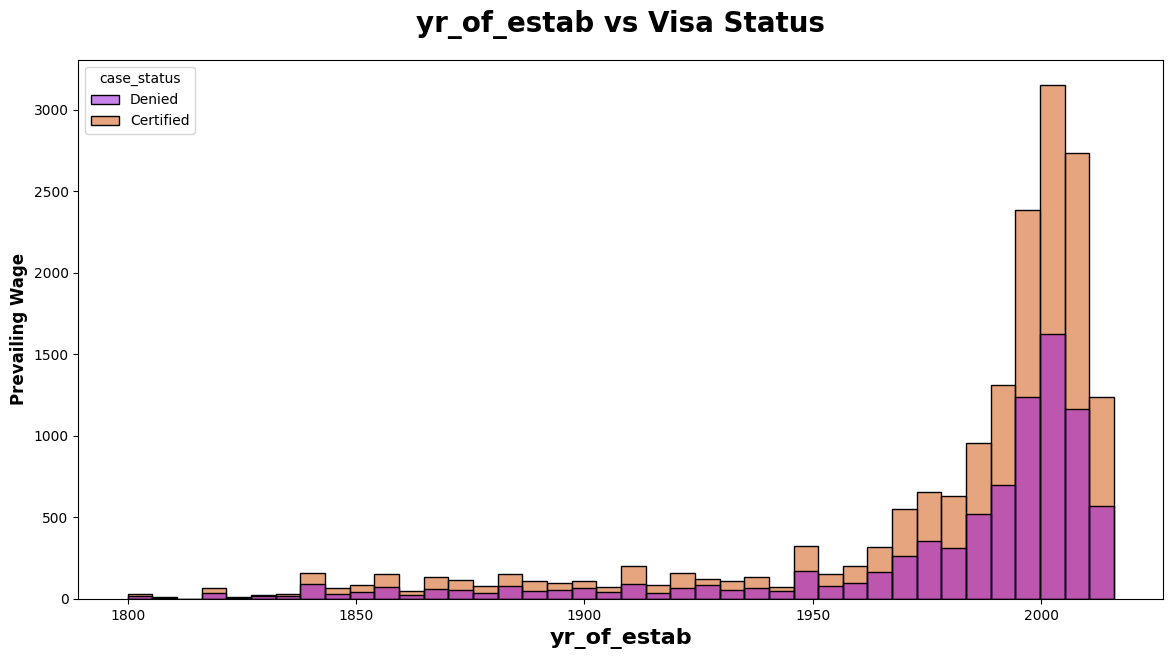

In [ ]:
plt.subplots(figsize=(14,7))
sns.histplot(x = "yr_of_estab", data=df,palette='gnuplot', bins=40, hue='case_status')
plt.title("yr_of_estab vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("yr_of_estab", weight="bold", fontsize=16)
plt.ylabel("Prevailing Wage", weight="bold", fontsize=12)
plt.show()

**Report**
* Each bins consists of 5 years.
* Many companies were established after year 2000.
* The most company establishment happened in year 2000-2005.

### Final Report 
* `case_id` column can be dropped as it is an ID.
* `requires_job_training` column can be dropped as it doesn't have much impact on target variable, Proved in visualization and chi2 test.
* `no_of_employees`, `prevailing_wage` columns have outllier which should be handled.
* `continent` columns has few unique values with very less count, which can be made as **others**
* Target column `case_status` is imbalanced can be handled before model building.

# EDA Final Report & Modeling Recommendations

## 4.1. Dataset Overview

- Total observations: 25,480
- Total features: 12
- Problem type: Binary Classification
- Target variable: `case_status`
- Target classes:
    - Certified: 66.79%
    - Denied: 33.21%

- Insight
    - The dataset contains 25,480 observations and 12 columns. The objective is to predict whether a visa application is Certified or Denied, making this a binary classification problem.


### 4.2 Data Quality Findings

- Missing values were investigated across all features.
- Duplicate records were checked.
- Data types were verified.
- Unique values and categorical cardinality were examined.
- Invalid or unexpected values were investigated.
- `case_id` contains unique identifiers for each observation.

- Modeling Decision
    - case_id does not represent meaningful applicant information and should be excluded from model training to prevent the model from learning identifier-specific patterns.

In [ ]:
########################-------------Feature Engineering and Model Training in Next ipynb------------###########################